<a href="https://colab.research.google.com/github/swirita/Adult-Income-Prediction/blob/main/Adult_Income_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Prediction

* **Author**: Siwar Ehwass

## Overview

### Context

This dataset comes from the 1994 US Census, collected by the UCI Machine Learning Repository. It is a widely cited **KNN dataset**, often used as a starting point for data pre-processing and machine learning practice. Each row is one person, and the goal is to predict whether their annual income is <=50K or >50K.

### Dataset Overview

**Target**

- `Income` — binary target: <=50K or >50K.

**Features**

- 14 attributes describing a person's demographics and work history (age, education, occupation, hours worked, marital status, etc.).
- The dataset has **48,842 rows** and **16 columns** in total (14 features + 1 target + 1 duplicate `education-num` column some versions include).

**Expected Challenges**

- Missing values are coded as `?` in columns like `workclass`, `occupation`, and `native-country`, so they need to be handled before modeling.
- The target is imbalanced — most people ear<=50Kso accuracy alone won't tell the full story.
- Mixed data types: numeric (age, hours-per-week) and categorical (education, marital-status) need different preprocessing.
- `fnlwgt` is a survey weight, not a real feature — it shouldn't be used for prediction.



Liu, W. (October 2016). Adult Income Dataset. Retrieved Aug. 7, 2026. [Dataset](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset).

The detailed description on the dataset can be found in the original UCI [documentation](http://www.cs.toronto.edu/~delve/data/adult/adultDetail.html).


Becker, B. & Kohavi, R. (1996). UCI Machine Learning Repository. [Source](https://doi.org/10.24432/C5XW20).




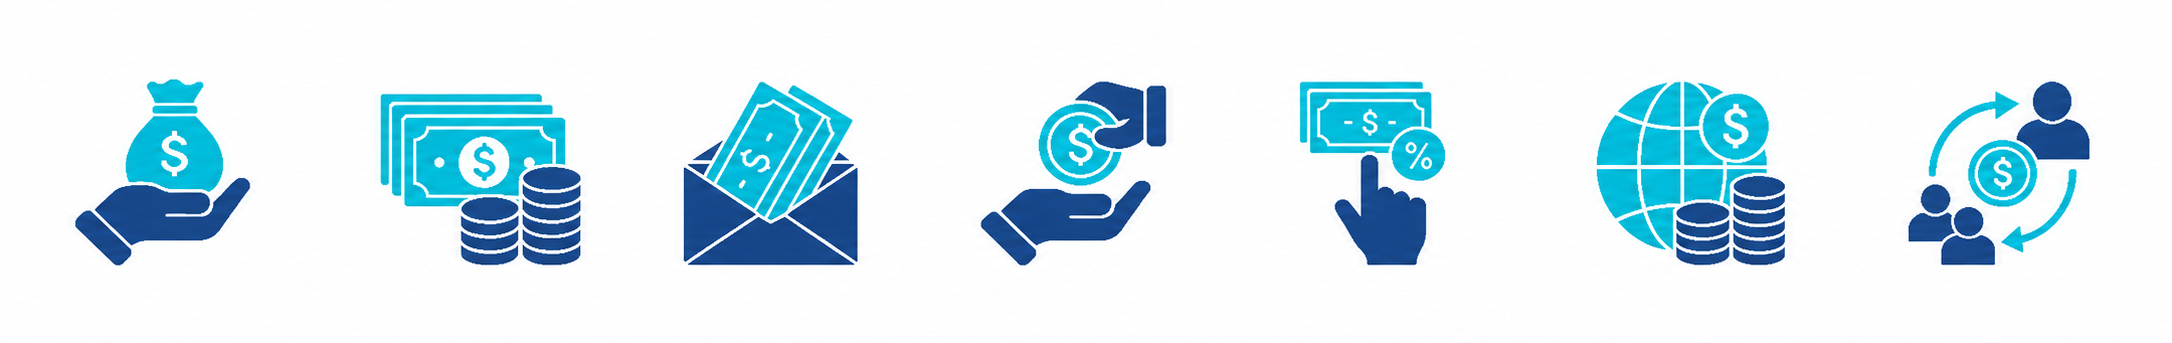

## Data Dictionary

| Column | Description |
|---|---|
| `age` | Age of the person |
| `workclass` | Type of employment |
| `fnlwgt` | Census weight assigned to the person |
| `education` | Highest education level |
| `educational-num` | Numerical representation of education level |
| `marital-status` | Marital status |
| `occupation` | Type of job |
| `relationship` | Relationship role in the household |
| `race` | Race category |
| `gender` | Gender of the person |
| `capital-gain` | Money gained from investments |
| `capital-loss` | Money lost from investments |
| `hours-per-week` | Number of working hours per week |
| `native-country` | Country of origin |
| `income` | Target: whether income is `<=50K` or `>50K` |

## Imports

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

print("Path to dataset files:", path)

import os
print(os.listdir("/kaggle/input/adult-income-dataset"))

Using Colab cache for faster access to the 'adult-income-dataset' dataset.
Path to dataset files: /kaggle/input/adult-income-dataset
['adult.csv', '.nfs00000000bfc178500000006b']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder, LabelBinarizer, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, silhouette_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.utils.class_weight import compute_class_weight

# Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import metrics
from tensorflow.keras.regularizers import l1_l2

import sys
if 'google.colab' in sys.modules:
  !pip install keras-tuner
from keras_tuner import HyperParameters as hp
import keras_tuner as kt

from sklearn import set_config
set_config(transform_output='pandas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.5 MB/s eta 0:00:00


## Load & Inspect Data

In [4]:
# create dataframe
df = pd.read_csv("/kaggle/input/adult-income-dataset/adult.csv")
# check information about df
df.info()
# check first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Observations

- The dataset has **48,842 rows** and **15 columns**.
- It contains **6 numerical** and **9 categorical** columns.
- `income` is the target with two classes: `<=50K` and `>50K`.
- Some missing values are stored as `?`.


## Data Cleaning & Feature Inspection

In [5]:
# check for duplicated data
print(f'\nbefore: {df.duplicated().sum()}')

# drop dupes
df= df.drop_duplicates()

# check again
print(f'\nafter: {df.duplicated().sum()}')


before: 52

after: 0


In [6]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
age,0.151670
workclass,0.018446
fnlwgt,58.460750
education,0.032794
educational-num,0.032794
marital-status,0.014347
occupation,0.030744
relationship,0.012298
race,0.010248
gender,0.004099


In [7]:
# filter out both num and object features
num_cols=df.select_dtypes('number').columns # select numbers
cat_cols=df.select_dtypes('object').columns # select objects

# loop through each one's value counts (objects)
for col in cat_cols:
    print(f'Value counts of {col}:\n {df[col].value_counts(dropna=False)} \n')

Value counts of workclass:
 workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64 

Value counts of education:
 education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64 

Value counts of marital-status:
 marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtyp

In [8]:
# handling missing values
df= df.replace('?', np.nan)

In [9]:
# handling native-country
df['native-country'] = df['native-country'].replace({
    'Holand-Netherlands': 'Netherlands',
    'Trinadad&Tobago': 'Trinidad&Tobago',
    'Columbia': 'Colombia'
})

In [10]:
# check describe for numbers (loop)
for col in num_cols:
    print(f'Describe for {col}\n {df[col].describe()}')

Describe for age
 count    48790.000000
mean        38.652798
std         13.708493
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64
Describe for fnlwgt
 count    4.879000e+04
mean     1.896690e+05
std      1.056172e+05
min      1.228500e+04
25%      1.175550e+05
50%      1.781385e+05
75%      2.376062e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64
Describe for educational-num
 count    48790.000000
mean        10.078807
std          2.570046
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: educational-num, dtype: float64
Describe for capital-gain
 count    48790.000000
mean      1080.217688
std       7455.905921
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64
Describe for capital-loss
 count    48790.000000
mean        87.595573
s

## Missing Values

- Fill Categorical Missing values with new cat "MISSING"

In [11]:
# see columns and rows where NaN is present in df
df.isna().sum()

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


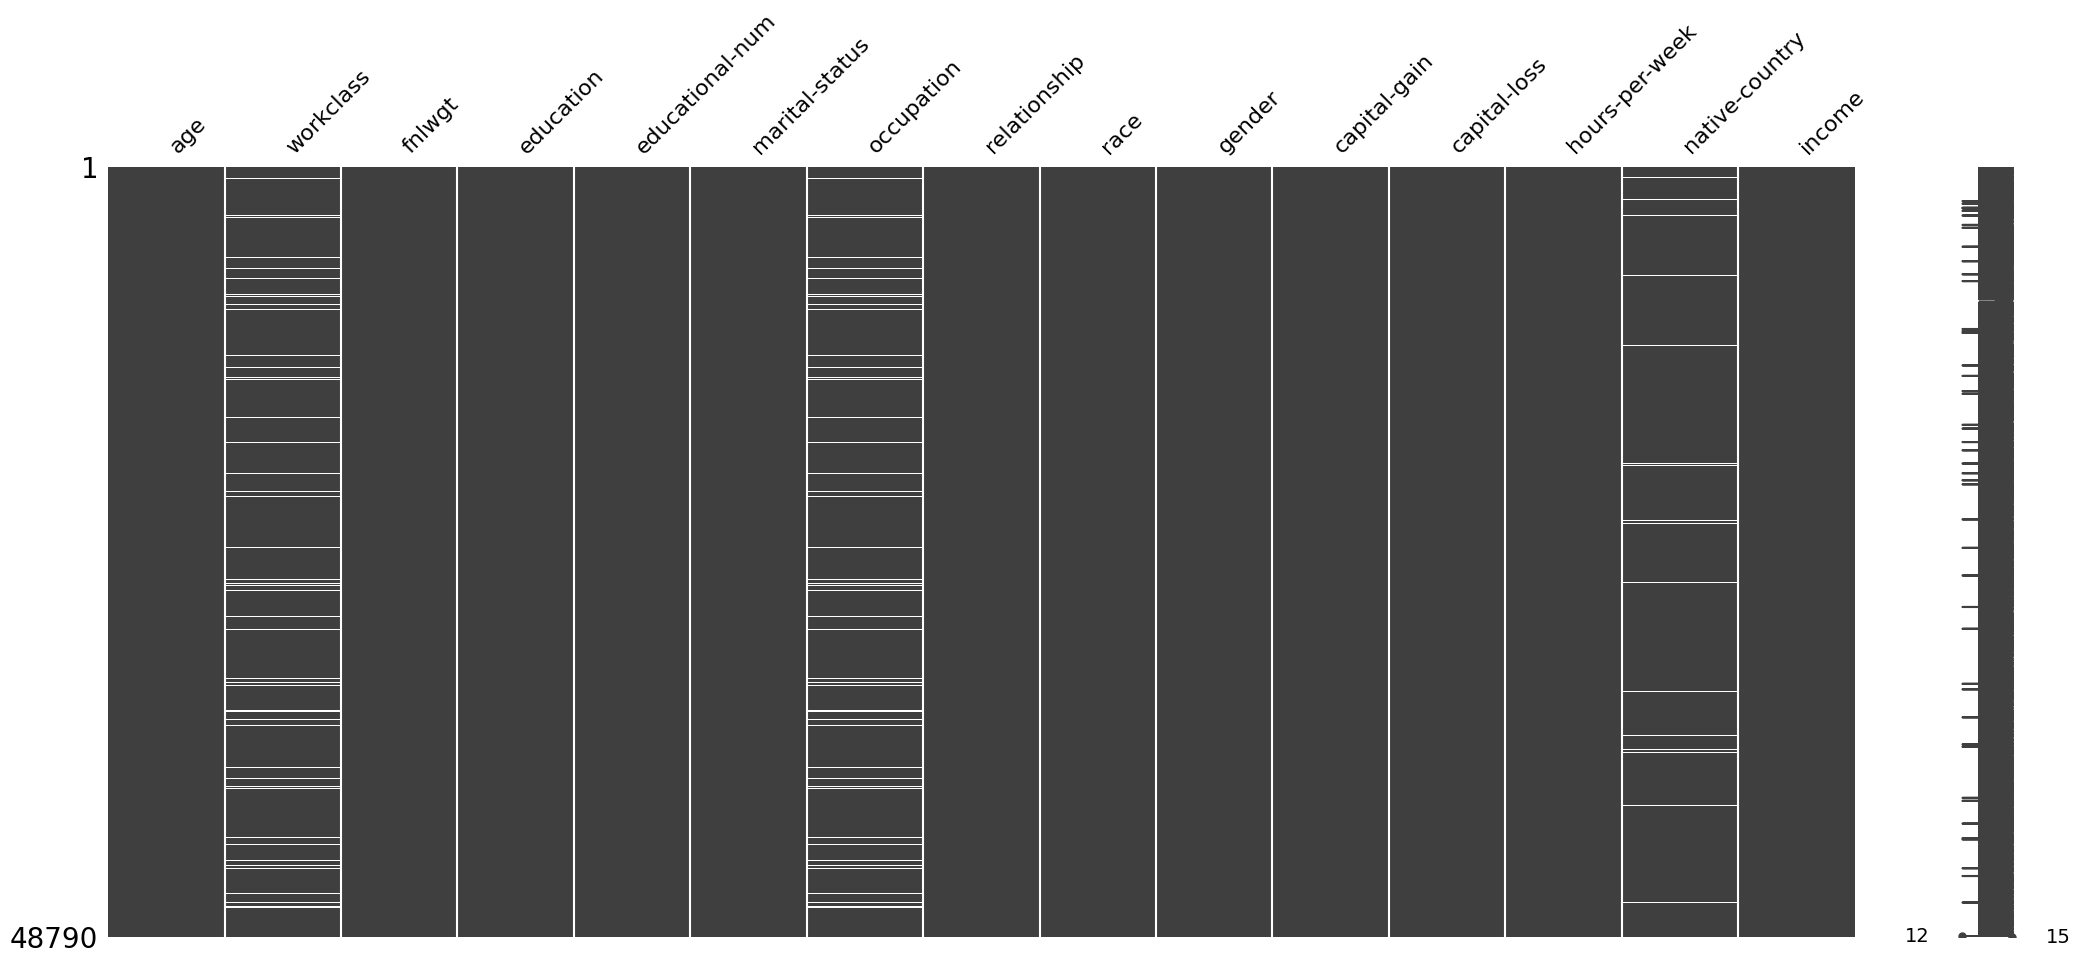

In [12]:
msno.matrix(df);

- workclass and occupation contain missing values of about the same pattern, which makes sense because if you dont know someones occupation itll make sense that you dont know their workclass as well, and vise versa

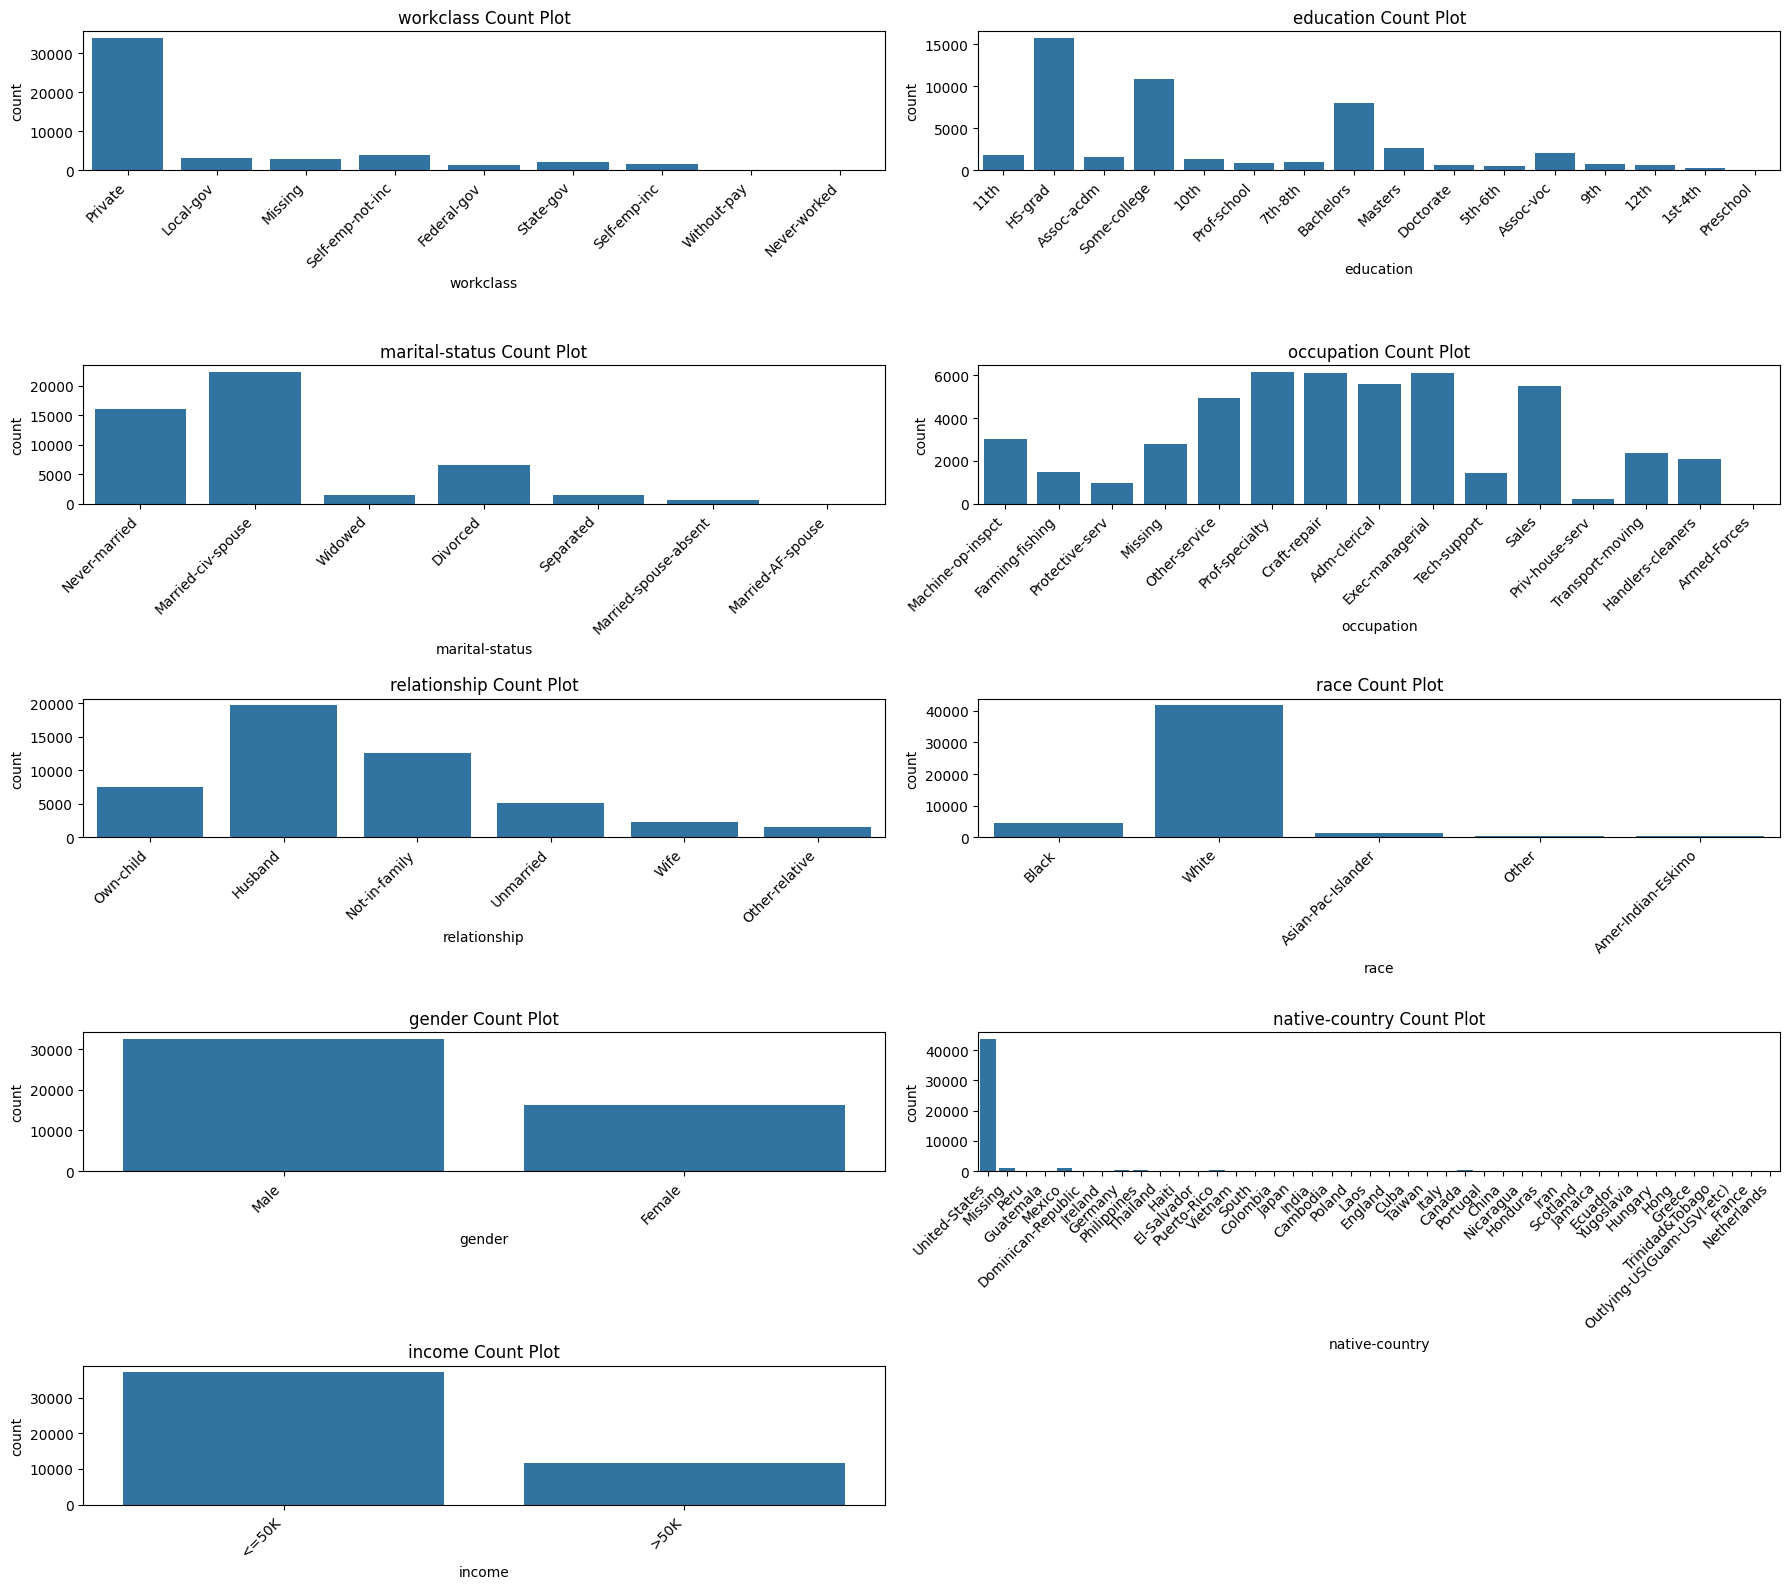

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Temporary copy for visualization only
    temp = df[col].fillna("Missing")

    sns.countplot(x=temp, ax=axes[i])

    axes[i].set_title(f"{col} Count Plot")
    axes[i].set_xlabel(col)

    # Rotate ticks and align right
    axes[i].tick_params(axis='x', rotation=45)

    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

 Insights

- `workclass` is mostly **Private**.
- `education` is mostly **HS-grad**, **Some-college**, and **Bachelors**.
- `marital-status` is mostly **Married-civ-spouse** and **Never-married**.
- `race` is mostly **White**.
- There are more **Male** records than **Female**.
- `native-country` is mostly **United-States**.
- `income` is imbalanced, with more `<=50K` records.

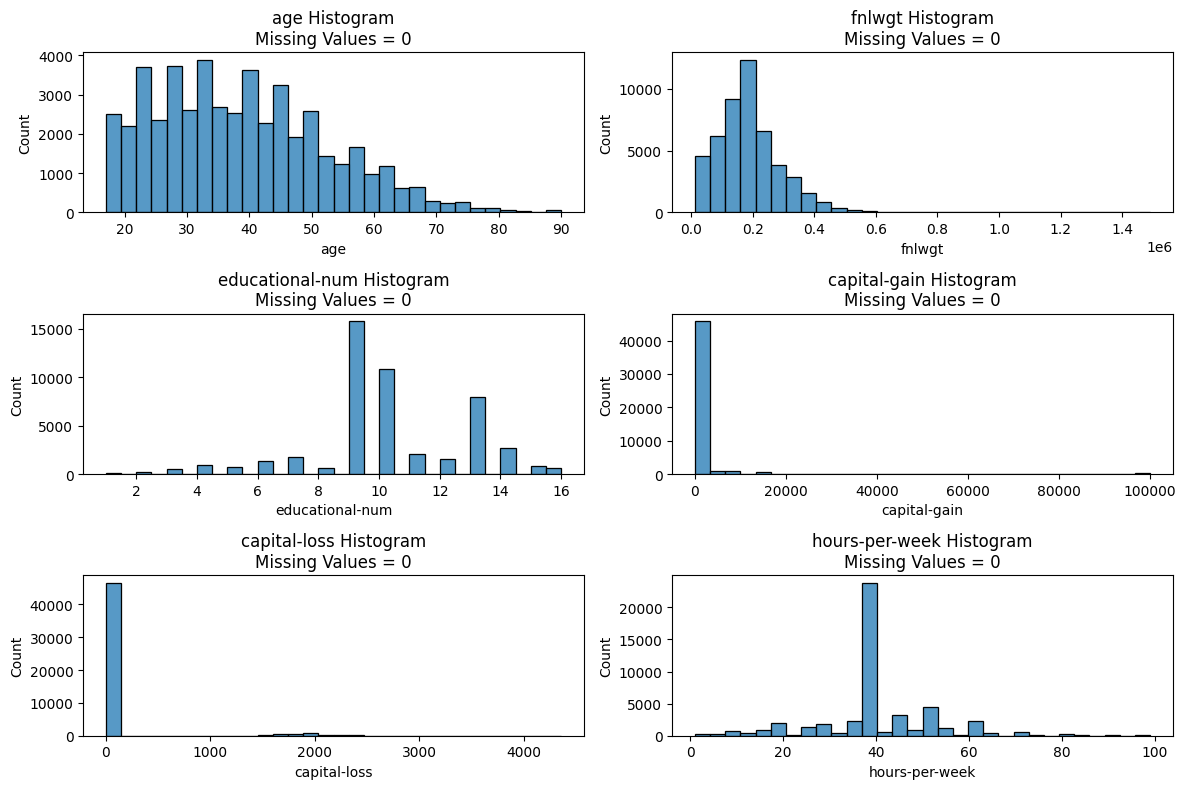

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    missing = df[col].isna().sum()

    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram\nMissing Values = {missing}")

plt.tight_layout()

- `age` is mostly between about **20 and 50**.
- `fnlwgt` is right-skewed with some large values.
- `capital-gain` and `capital-loss` are mostly **0**.
- `hours-per-week` is mostly around **40 hours**.
- There are no missing values in numerical columns.

## Exploratry Data Analysis

In [15]:
target = 'income'

categorical_cols = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
]

ordinal_cols = [
    'education',
    'educational-num'
]

numerical_cols = [
    'age',
    'fnlwgt',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

In [16]:
df[target].value_counts(normalize=True)

,proportion
income,
<=50K,0.760586
>50K,0.239414


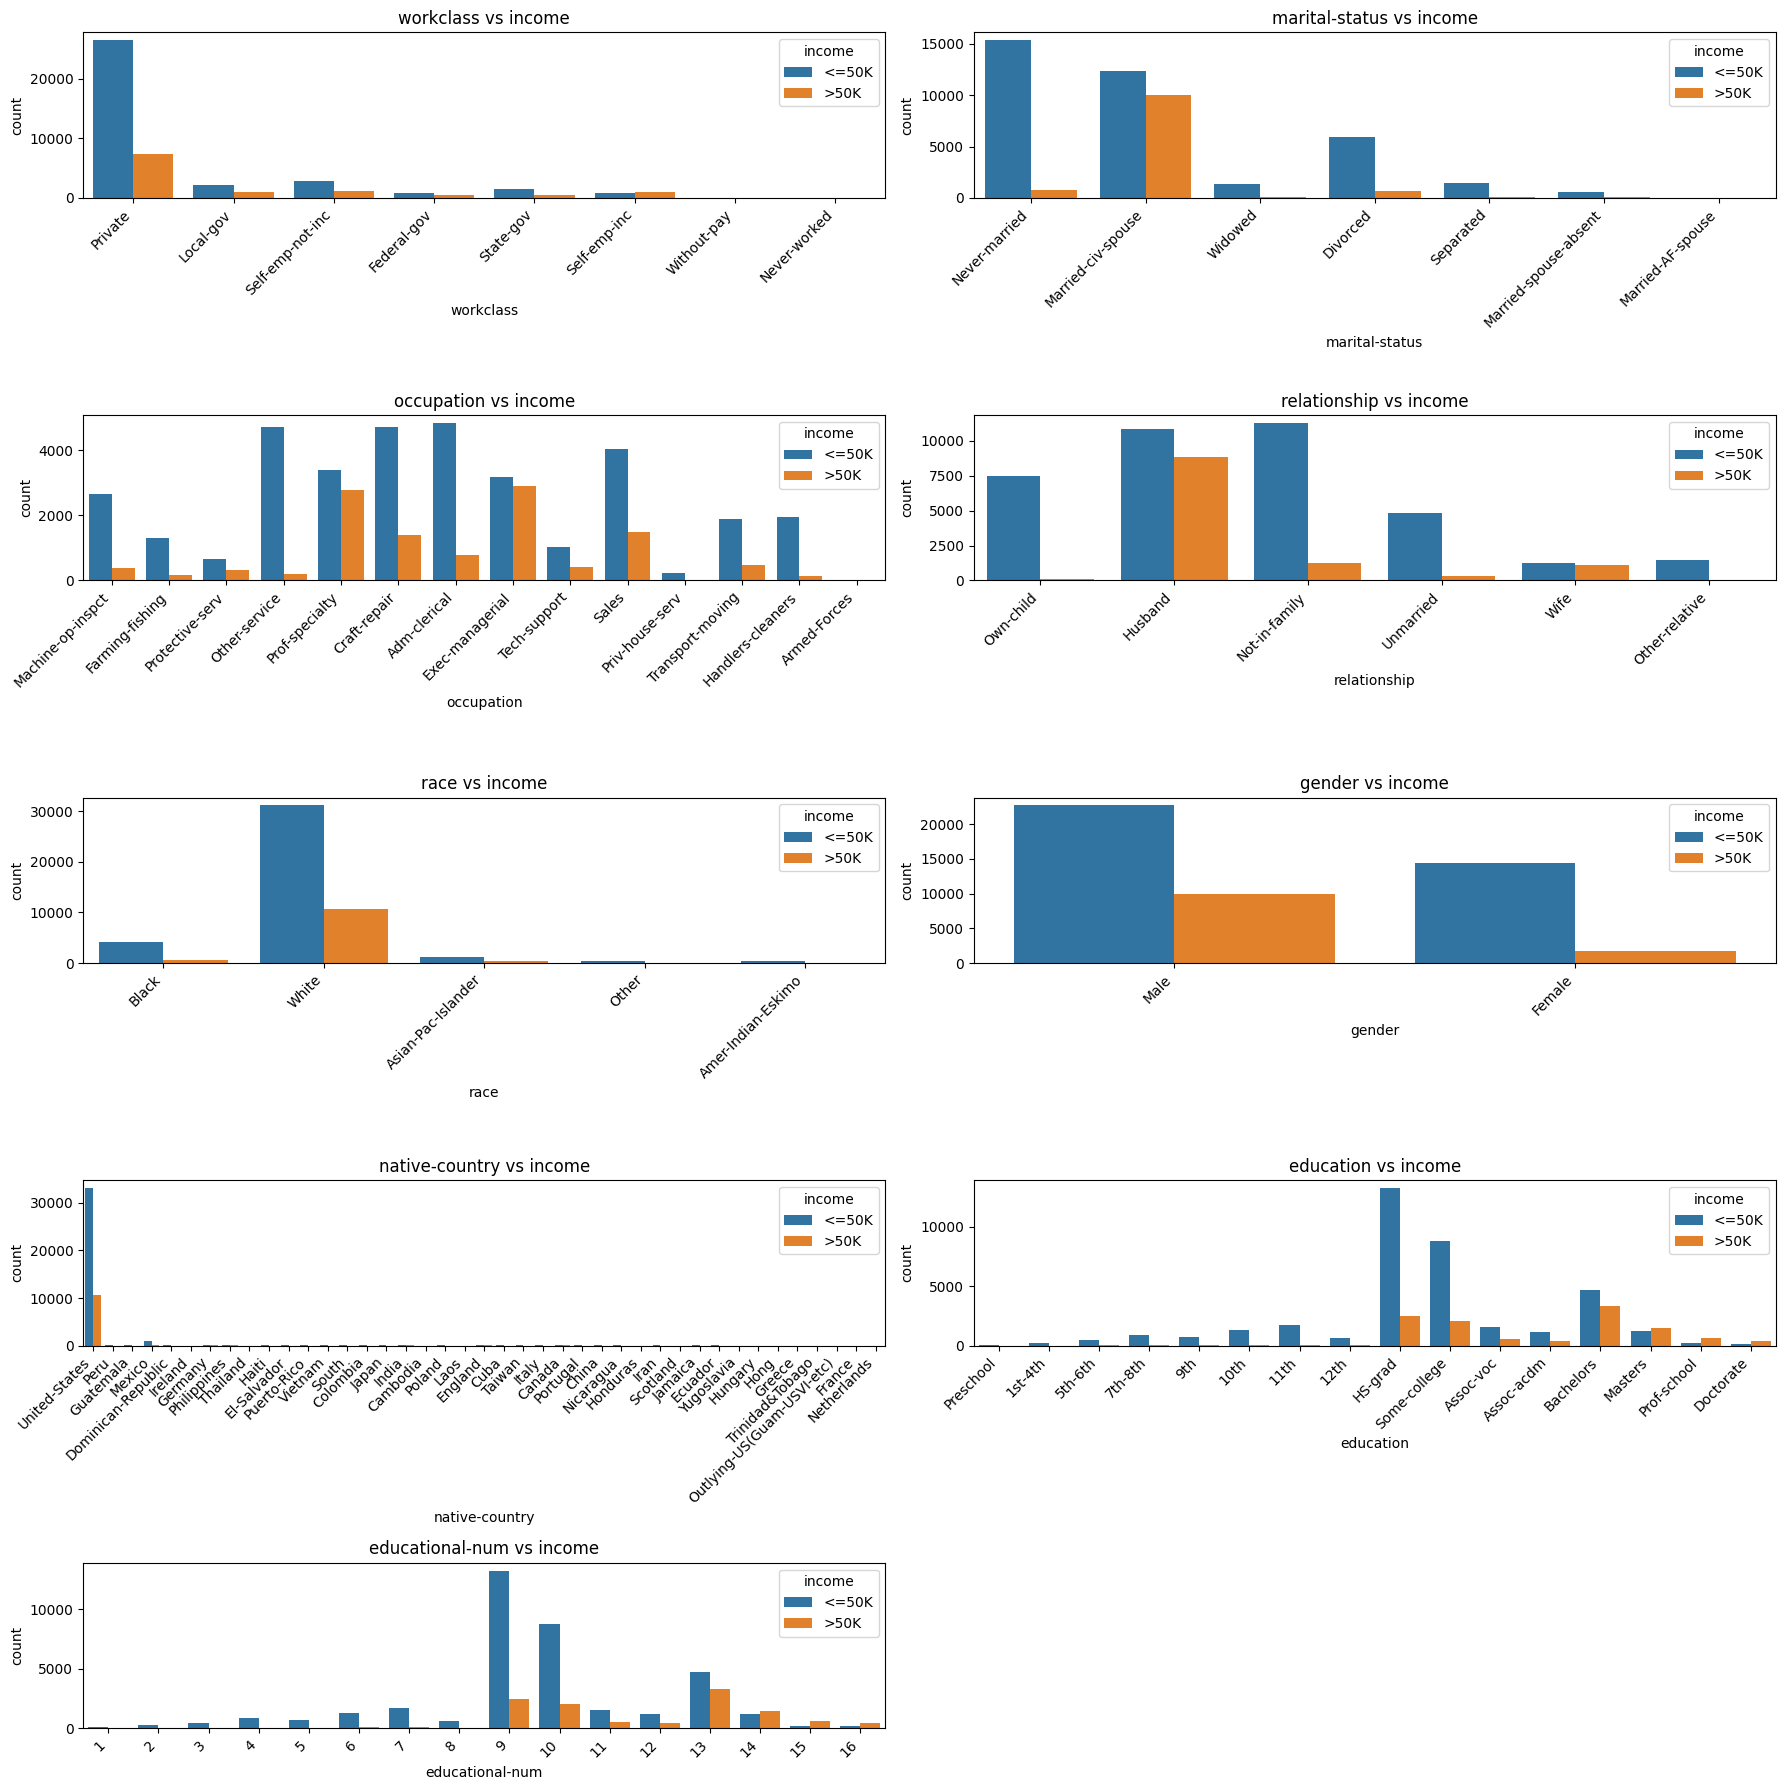

In [17]:
category_orders = {
    'education': ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad',
                  'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'],
    'educational-num': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
}

features = categorical_cols + ordinal_cols

fig, axes = plt.subplots(5, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(features):

    sns.countplot(
        data=df,
        x=col,
        hue=target,
        order=category_orders.get(col),
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs income')
    axes[i].tick_params(axis='x', rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment('right')

# Remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- `Private` is the most common workclass for both income groups.
- `Married-civ-spouse` has many more `>50K` cases than other marital groups.
- `Exec-managerial` and `Prof-specialty` show many high-income cases.
- `Husband` has a high number of `>50K` cases.
- Most records are `White` and `Male`, so raw counts are affected by group size.
- `United-States` strongly dominates `native-country`.
- Higher education levels such as `Bachelors`, `Masters`, `Prof-school`, and `Doctorate` have more `>50K` cases.

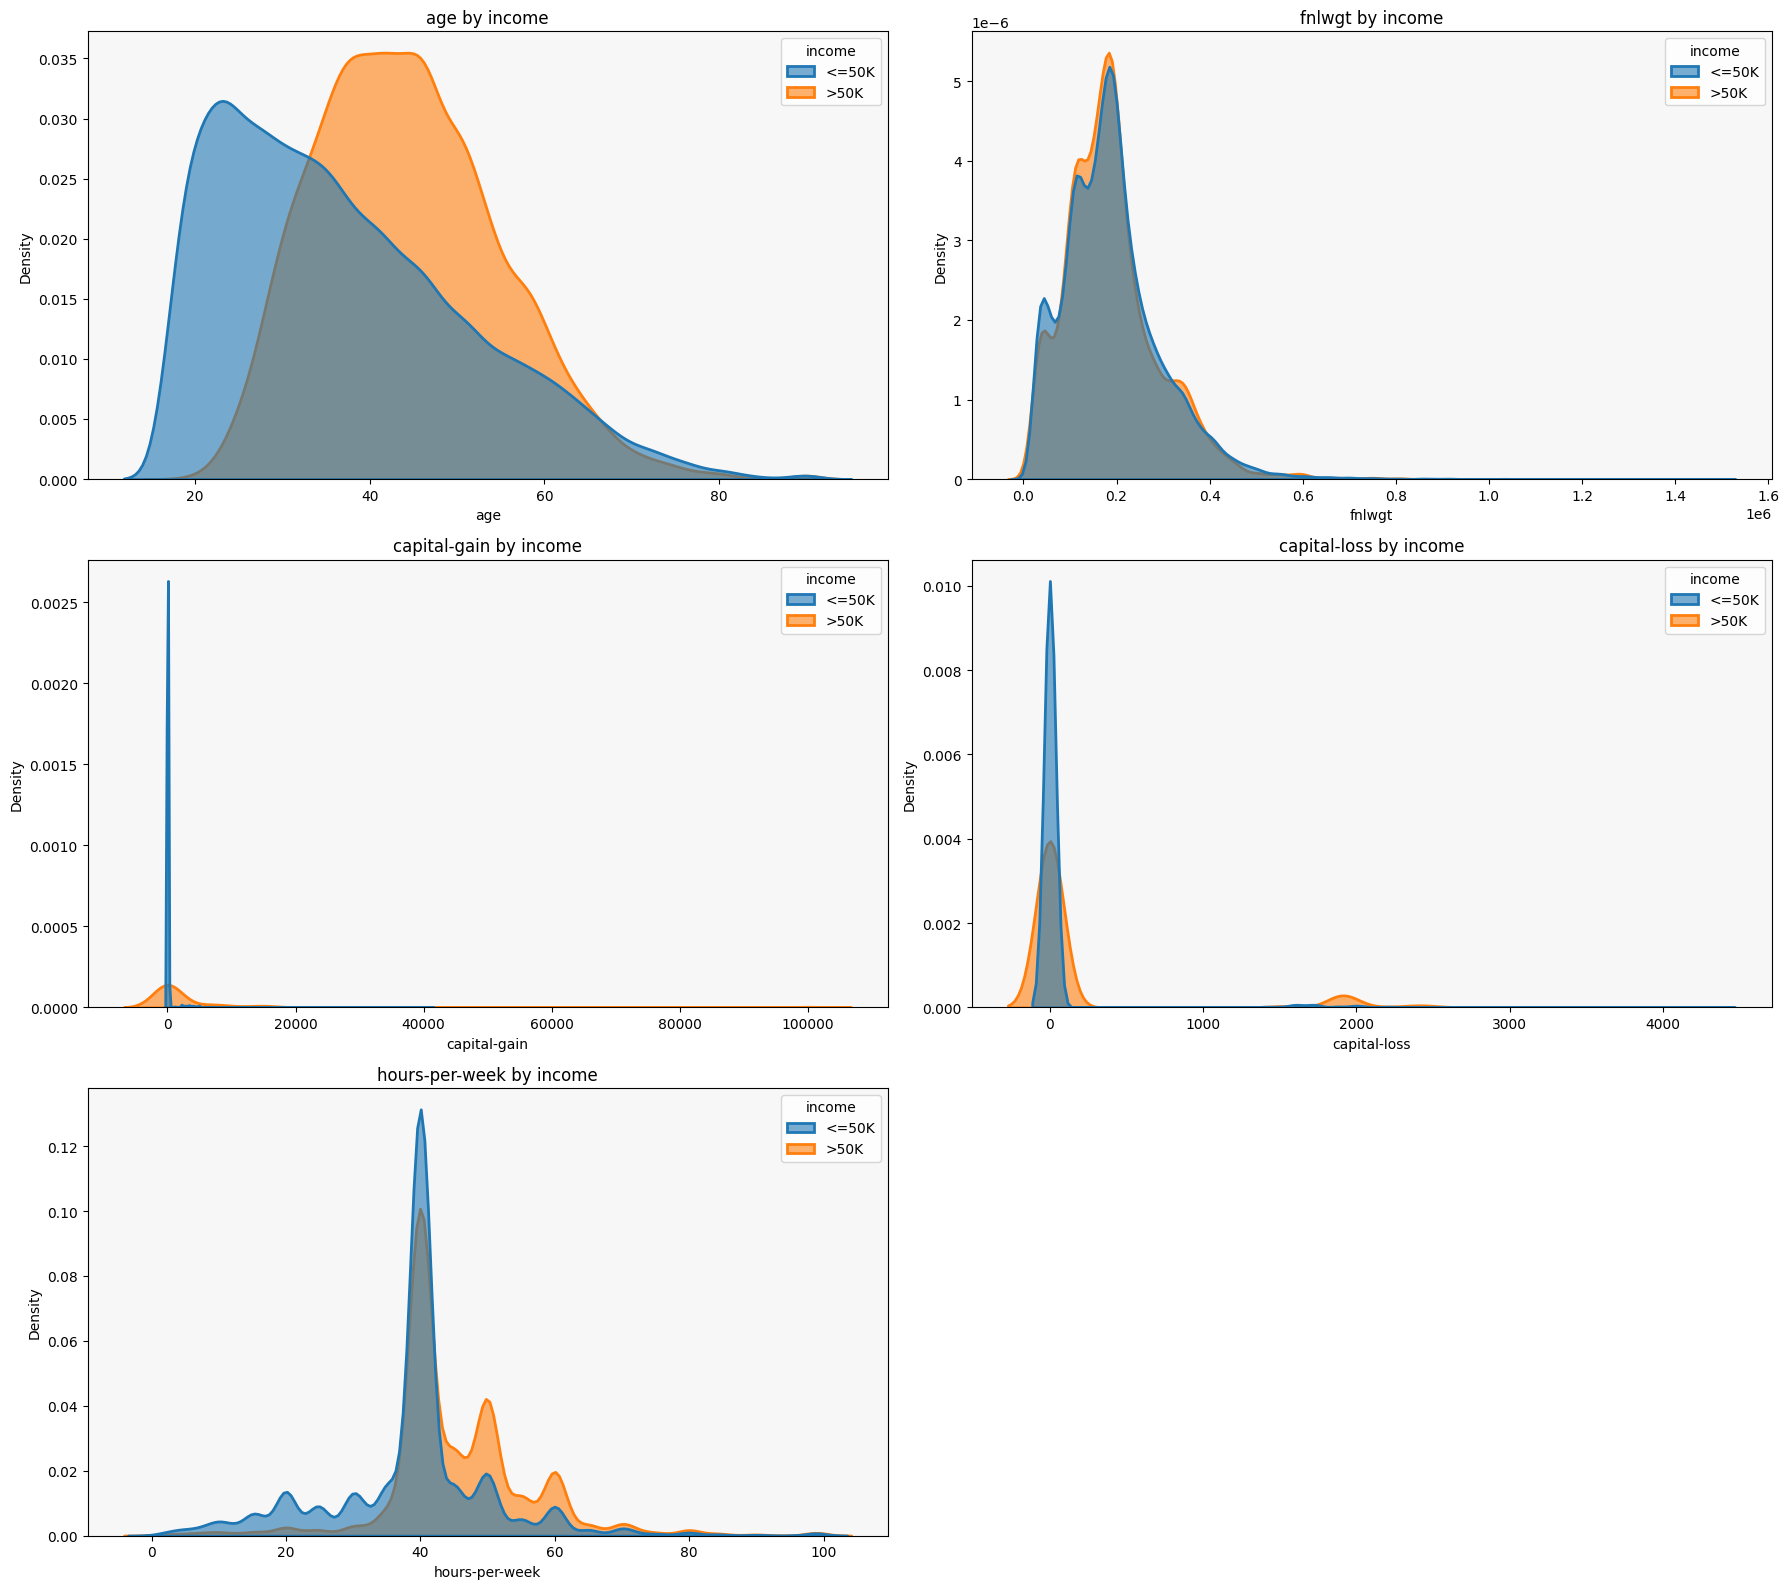

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):

    subset = df[[feature, target]].dropna()

    sns.kdeplot(
        data=subset,
        x=feature,
        hue=target,
        common_norm=False,
        fill=True,
        alpha=0.6,
        linewidth=2,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} by income')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].set_facecolor("#f7f7f7")

# Remove unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- People earning `>50K` are mostly concentrated at older ages, especially around 35–55.
- `fnlwgt` looks very similar for both income groups.
- `capital-gain` and `capital-loss` are mostly 0, but non-zero values appear more often in the `>50K` group.
- People earning `>50K` tend to work more hours per week.
- Around 40 hours per week is the most common value for both groups.

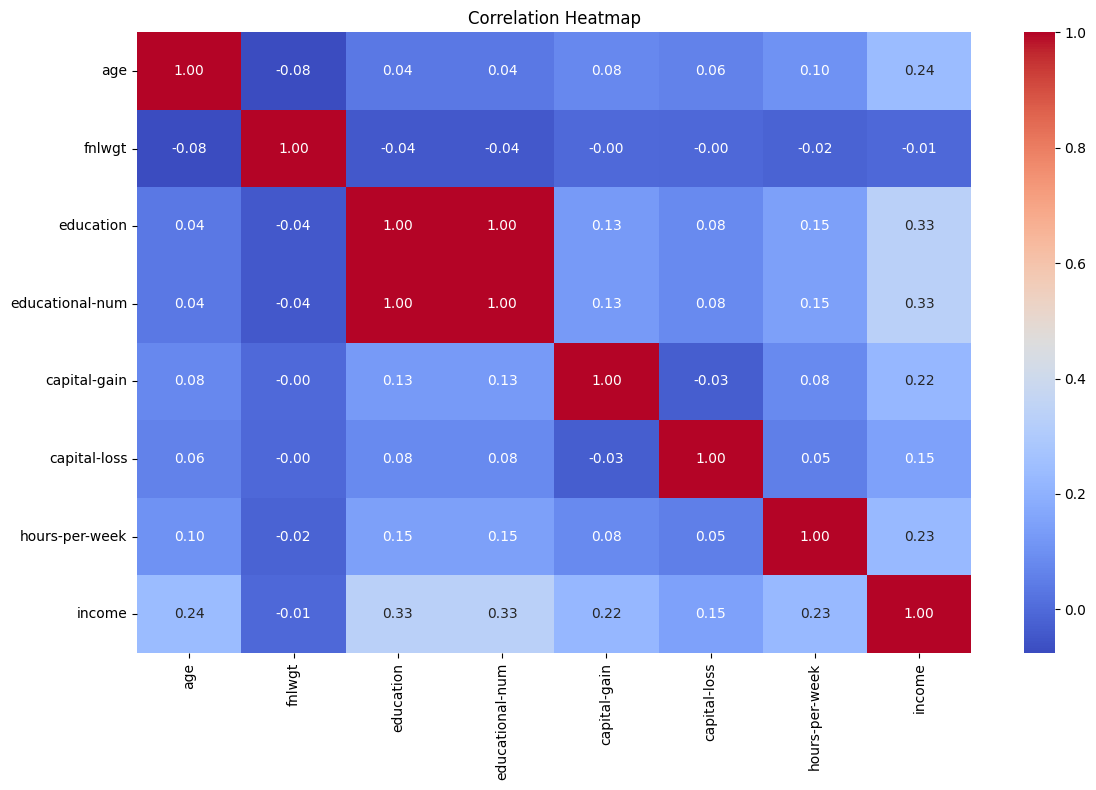

In [19]:
df_corr = df.copy()

# Drop rows with missing categorical values for correlation only
df_corr = df_corr.dropna(
    subset=['workclass', 'occupation', 'native-country']
).reset_index(drop=True)

# Ordinal encode education
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th',
    '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc',
    'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

education_encoder = OrdinalEncoder(categories=[education_order])

df_corr[['education']] = education_encoder.fit_transform(
    df_corr[['education']]
)

# Encode target
income_encoder = LabelEncoder()

df_corr['income'] = income_encoder.fit_transform(
    df_corr['income']
)

# Drop nominal categorical columns
df_corr = df_corr.drop(columns=[
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
])

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.tight_layout()

- `education` and `educational-num` have a correlation of `1.00`, so they contain the same information.
- `education` / `educational-num` has the strongest correlation with `income` at about `0.33`.
- `age`, `hours-per-week`, and `capital-gain` also have positive relationships with `income`.
- `capital-loss` has a weaker positive relationship with `income`.
- `fnlwgt` has almost no relationship with `income`.
- No strong multicollinearity appears between the other numerical features.

## Preprocessing

In [20]:
# split data
y = df[target]
X = df.drop(columns=[target, 'educational-num'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

# encode target for xgb
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# ordinal category orders
education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad',
                  'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']

ord_pipe= make_pipeline(
    OrdinalEncoder(categories=[education_order]),
    StandardScaler())

ord_tuple = ('Ordinal', ord_pipe, ['education'])

# Nominal
ohe_cols = (X_train.select_dtypes(include='object').columns.drop('education'))

ohe_pipe = make_pipeline(
  SimpleImputer(strategy='constant', fill_value='MISSING'),
  OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))

ohe_tuple = ('Categorical', ohe_pipe , ohe_cols)

# Numbers
skewed_cols = ['fnlwgt', 'capital-gain', 'capital-loss']
num_cols = (X_train.select_dtypes(include='number').columns.drop(skewed_cols))

num_tuple= ('Numeric', StandardScaler(), num_cols)

skewed_pipe = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler())

skewed_tuple=('Skewed Numeric', skewed_pipe, skewed_cols)

preprocessor = ColumnTransformer(
    [num_tuple, skewed_tuple, ord_tuple, ohe_tuple],
    verbose_feature_names_out=False)

In [21]:
# Model Evaluation Function
def classification_metrics(y_true,y_pred,label='',output_dict=False,figsize=(8, 4),normalize='true',cmap='Blues',colorbar=False):
    # Get the classification report
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "--" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Create a confusion matrix of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=None,cmap='gist_gray',colorbar=colorbar,ax=axes[0])
    axes[0].set_title("Raw Counts")

    # Create a normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=normalize,cmap=cmap,colorbar=colorbar,ax=axes[1] )
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary version of classification_report
    if output_dict == True:
        report_dict = classification_report(
            y_true,
            y_pred,
            output_dict=True
        )
        return report_dict
def evaluate_classification(model,X_train,y_train,X_test,y_test,figsize=(6, 4),normalize='true',output_dict=False,cmap_train="Blues",cmap_test="Reds",colorbar=False):
    # Get predictions for training data
    y_train_pred = model.predict(X_train)

    # Call the helper function to obtain classification metrics for training data
    results_train = classification_metrics(y_train,y_train_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')

    print()

    # Get predictions for test data
    y_test_pred = model.predict(X_test)

    # Call the helper function to obtain classification metrics for test data
    results_test = classification_metrics( y_test, y_test_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data')

    if output_dict == True:
        # Store results in a dictionary if output_dict is True
        results_dict = {
            'train': results_train,
            'test': results_test
        }
        return results_dict

## Model: KNN

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.91      0.93      0.92     27831
        >50K       0.77      0.72      0.74      8761

    accuracy                           0.88     36592
   macro avg       0.84      0.83      0.83     36592
weighted avg       0.88      0.88      0.88     36592



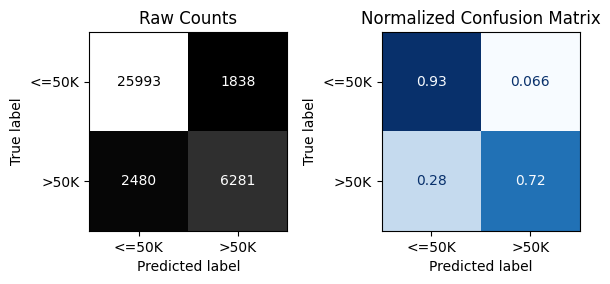


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.90      0.89      9278
        >50K       0.66      0.62      0.64      2920

    accuracy                           0.83     12198
   macro avg       0.77      0.76      0.77     12198
weighted avg       0.83      0.83      0.83     12198



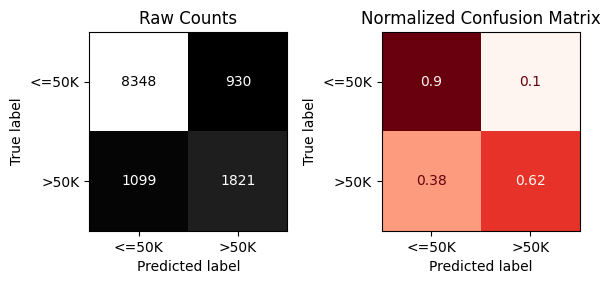

In [27]:
# default KNN
knn= KNeighborsClassifier()

knn_pipe=make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

# evaluate
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

In [28]:
# nneighbors_list = [25, 31, 35, 41, 51]

# params = {
#     'kneighborsclassifier__n_neighbors': nneighbors_list,
#     'kneighborsclassifier__weights': ['uniform', 'distance'],
#     'kneighborsclassifier__metric': ['manhattan']
# }

# gridsearch = GridSearchCV(
#     knn_pipe,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# gridsearch.fit(X_train, y_train)

# print(gridsearch.best_params_)
# print(gridsearch.best_score_)

# best_knn = gridsearch.best_estimator_

# evaluate_classification(
#     best_knn,
#     X_train,
#     y_train,
#     X_test,
#     y_test
# )

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91     27831
        >50K       0.72      0.65      0.68      8761

    accuracy                           0.86     36592
   macro avg       0.81      0.78      0.79     36592
weighted avg       0.85      0.86      0.85     36592



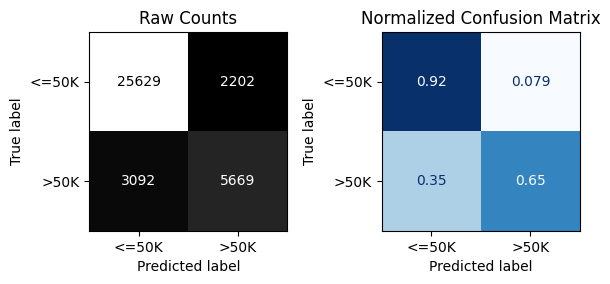


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      9278
        >50K       0.70      0.63      0.67      2920

    accuracy                           0.85     12198
   macro avg       0.80      0.77      0.78     12198
weighted avg       0.84      0.85      0.85     12198



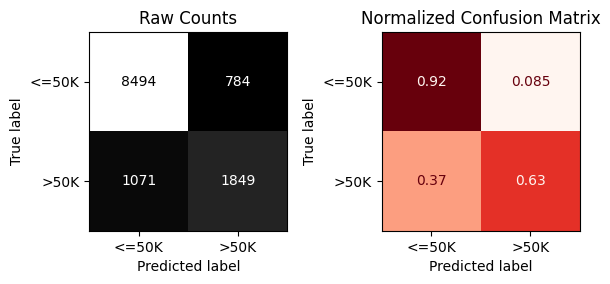

In [29]:
# tuned KNN
knn= KNeighborsClassifier(metric='manhattan',
                          n_neighbors= 51,
                          weights= 'uniform')

knn_pipe=make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

# evaluate
evaluate_classification(knn_pipe, X_train, y_train, X_test, y_test)

## Model: Random Forest

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     27831
        >50K       1.00      1.00      1.00      8761

    accuracy                           1.00     36592
   macro avg       1.00      1.00      1.00     36592
weighted avg       1.00      1.00      1.00     36592



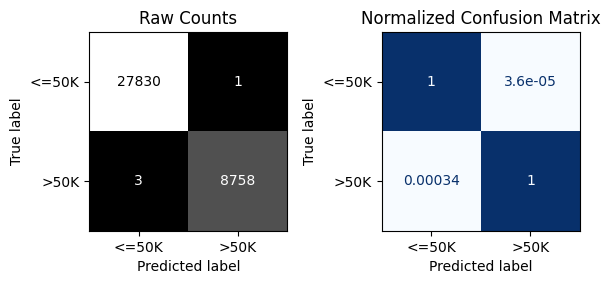


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      9278
        >50K       0.74      0.62      0.67      2920

    accuracy                           0.86     12198
   macro avg       0.81      0.77      0.79     12198
weighted avg       0.85      0.86      0.85     12198



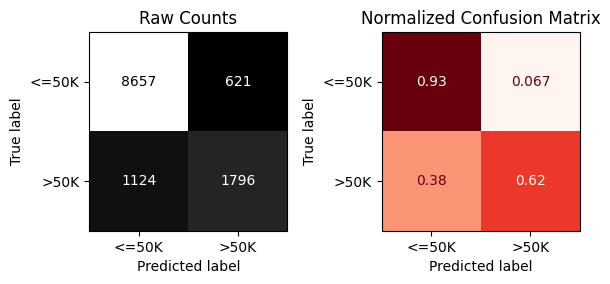

In [22]:
# default model
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

In [23]:
# params = {
#     'randomforestclassifier__n_estimators': [200],
#     'randomforestclassifier__max_depth': [20, 25, 30, None],
#     'randomforestclassifier__min_samples_split': [3, 5],
#     'randomforestclassifier__min_samples_leaf': [1, 2],
#     'randomforestclassifier__max_features': ['sqrt'],
#     'randomforestclassifier__class_weight': ['balanced_subsample']
# }

# # Grid Search
# gridsearch = GridSearchCV(
#     rf_pipe,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# # Train
# gridsearch.fit(X_train, y_train)

# # Best parameters
# print("\nBest Parameters:")
# print(gridsearch.best_params_)

# print("\nBest CV Macro F1:")
# print(gridsearch.best_score_)

# # Best model
# best_rf = gridsearch.best_estimator_

# # Evaluate
# evaluate_classification(best_rf, X_train, y_train, X_test, y_test)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.99      0.91      0.95     27831
        >50K       0.78      0.97      0.86      8761

    accuracy                           0.93     36592
   macro avg       0.88      0.94      0.91     36592
weighted avg       0.94      0.93      0.93     36592



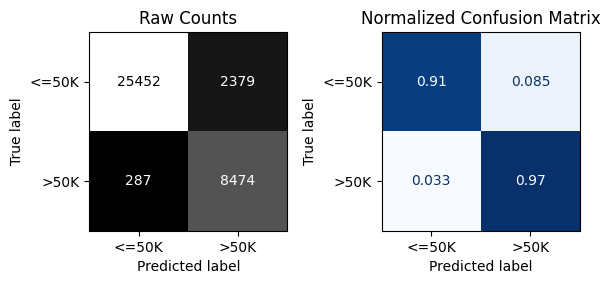


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.93      0.87      0.90      9278
        >50K       0.65      0.78      0.71      2920

    accuracy                           0.85     12198
   macro avg       0.79      0.82      0.80     12198
weighted avg       0.86      0.85      0.85     12198



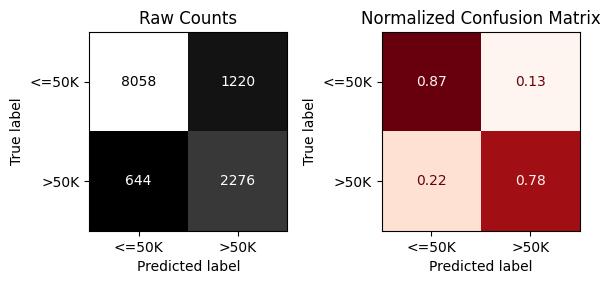

In [24]:
# tuned rf model
rf = RandomForestClassifier(random_state=42,
                            class_weight= 'balanced_subsample',
                            max_depth= 30,
                            max_features= 'sqrt',
                            min_samples_leaf= 1,
                            min_samples_split= 5,
                            n_estimators= 200)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)

evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

## Model: XGBoost

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     27831
           1       0.84      0.71      0.77      8761

    accuracy                           0.90     36592
   macro avg       0.87      0.83      0.85     36592
weighted avg       0.89      0.90      0.89     36592



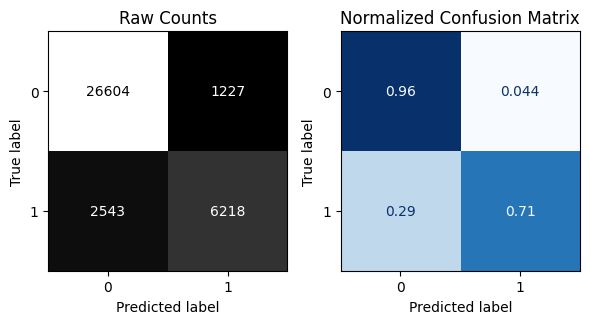


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      9278
           1       0.78      0.65      0.71      2920

    accuracy                           0.87     12198
   macro avg       0.84      0.80      0.81     12198
weighted avg       0.87      0.87      0.87     12198



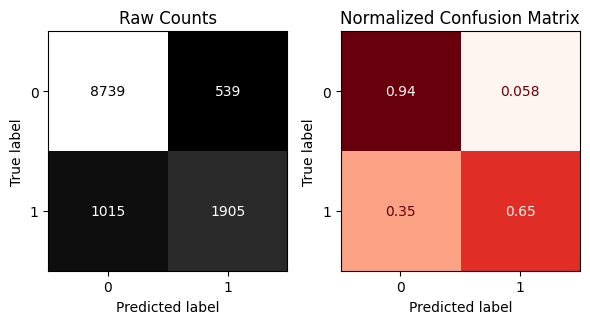

In [25]:
# default xgb model
xgb= XGBClassifier(random_state=42)
xgb_pipe = make_pipeline(preprocessor, xgb)

xgb_pipe.fit(X_train, y_train_encoded)

evaluate_classification(
    xgb_pipe,
    X_train, y_train_encoded,
    X_test, y_test_encoded
)

Fitting 3 folds for each of 192 candidates, totalling 576 fits

Best Parameters:
{'xgbclassifier__colsample_bytree': 1.0, 'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__scale_pos_weight': 1.5, 'xgbclassifier__subsample': 1.0}

Best CV Score:
0.819963201425529
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     27831
           1       0.75      0.76      0.76      8761

    accuracy                           0.88     36592
   macro avg       0.84      0.84      0.84     36592
weighted avg       0.88      0.88      0.88     36592



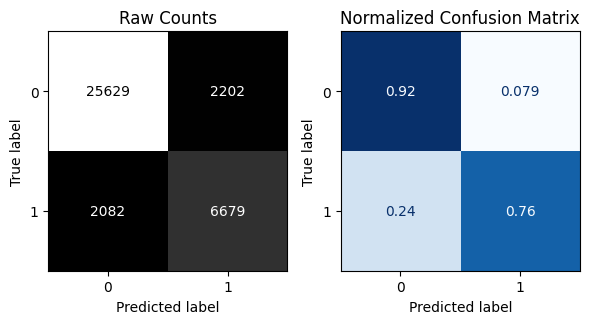


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      9278
           1       0.72      0.73      0.73      2920

    accuracy                           0.87     12198
   macro avg       0.82      0.82      0.82     12198
weighted avg       0.87      0.87      0.87     12198



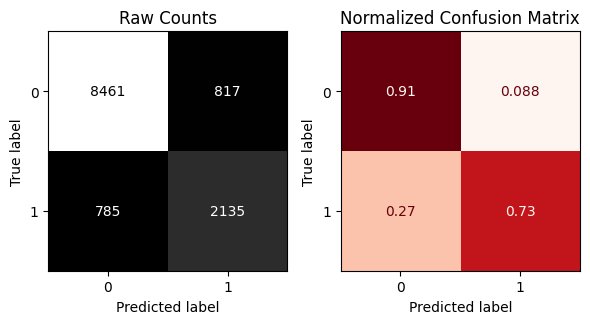

In [28]:
# params = {
#     'xgbclassifier__n_estimators': [100, 200],
#     'xgbclassifier__max_depth': [3, 5, 7],
#     'xgbclassifier__learning_rate': [0.03, 0.1],
#     'xgbclassifier__subsample': [0.8, 1.0],
#     'xgbclassifier__colsample_bytree': [0.8, 1.0],
#     'xgbclassifier__scale_pos_weight': [1, 1.5, 2, 2.5]
# }

# gridsearch_xgb = GridSearchCV(
#     xgb_pipe,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# gridsearch_xgb.fit(X_train, y_train_encoded)

# print("\nBest Parameters:")
# print(gridsearch_xgb.best_params_)

# print("\nBest CV Score:")
# print(gridsearch_xgb.best_score_)

# best_xgb = gridsearch_xgb.best_estimator_

# evaluate_classification(
#     best_xgb,
#     X_train,
#     y_train_encoded,
#     X_test,
#     y_test_encoded
# )

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     27831
           1       0.75      0.76      0.76      8761

    accuracy                           0.88     36592
   macro avg       0.84      0.84      0.84     36592
weighted avg       0.88      0.88      0.88     36592



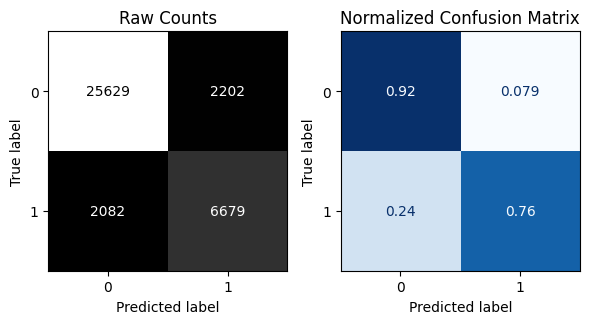


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      9278
           1       0.72      0.73      0.73      2920

    accuracy                           0.87     12198
   macro avg       0.82      0.82      0.82     12198
weighted avg       0.87      0.87      0.87     12198



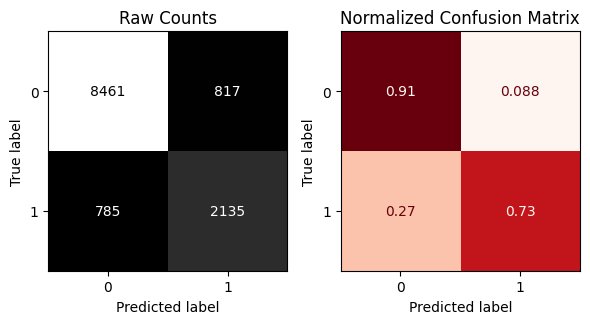

In [55]:
# tuned xgb model
xgb= XGBClassifier(random_state=42,
                   learning_rate=0.1,
                   max_depth=7,
                   n_estimators=100,
                   subsample=1.0,
                   colsample_bytree=1.0,
                   scale_pos_weight= 1.5)
xgb_pipe = make_pipeline(preprocessor, xgb)

xgb_pipe.fit(X_train, y_train_encoded)

evaluate_classification(
    xgb_pipe,
    X_train, y_train_encoded,
    X_test, y_test_encoded
)

| Model                   | Train Macro F1 | Test Macro F1 | Overfit Gap | Test Accuracy | `<=50K` Recall | `>50K` Recall | `>50K` F1 |
| ----------------------- | -------------: | ------------: | ----------: | ------------: | -------------: | ------------: | --------: |
| **Final KNN**           |           0.79 |          0.78 |    **0.01** |          0.85 |       **0.91** |          0.64 |      0.67 |
| **Final Random Forest** |           0.91 |          0.80 |        0.11 |          0.85 |           0.87 |      **0.78** |  **0.71** |
| **Final XGBoost**       |           0.83 |      **0.82** |    **0.01** |      **0.87** |       **0.94** |          0.66 |  **0.71** |


## Explanatory Data Analysis

In [29]:
def get_color_dict(importances, color_rest='#104088', color_top='#00B8D8', top_n=5):
    highlight_feats = importances.sort_values(ascending=False).head(top_n).index
    return {col: color_top if col in highlight_feats else color_rest for col in importances.index}

def plot_importance_color(importances, top_n=10, highlight_n=5, figsize=(9, 6.5)):
    plot_vals = importances.sort_values(ascending=False).head(top_n)
    color_dict = get_color_dict(importances, color_rest='#104088', color_top='#00B8D8', top_n=highlight_n)
    plot_vals = plot_vals.sort_values()
    colors = plot_vals.index.map(color_dict)

    fig, ax = plt.subplots(figsize=figsize, dpi=180)
    bars = ax.barh(plot_vals.index, plot_vals.values, color=colors, height=0.7, zorder=3)

    max_val = plot_vals.max()
    offset = max_val * 0.02
    ax.set_xlim(0, max_val * 1.15)

    for bar, value in zip(bars, plot_vals.values):
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f'{value*100:.1f}%',
                va='center', ha='left', fontsize=9, fontweight='bold')

    ax.set_title(f'Top {top_n} Features by Permutation Importance', fontsize=16, fontweight='bold', pad=14)
    ax.set_xlabel('Permutation Importance', fontsize=11)
    ax.set_ylabel('Features', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.25, zorder=0)
    ax.set_axisbelow(True)

    plt.tight_layout()
    return ax

In [30]:
# Calculate permutation importance using unseen test data
r = permutation_importance(
    xgb_pipe,
    X_test,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

# Check the returned results
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

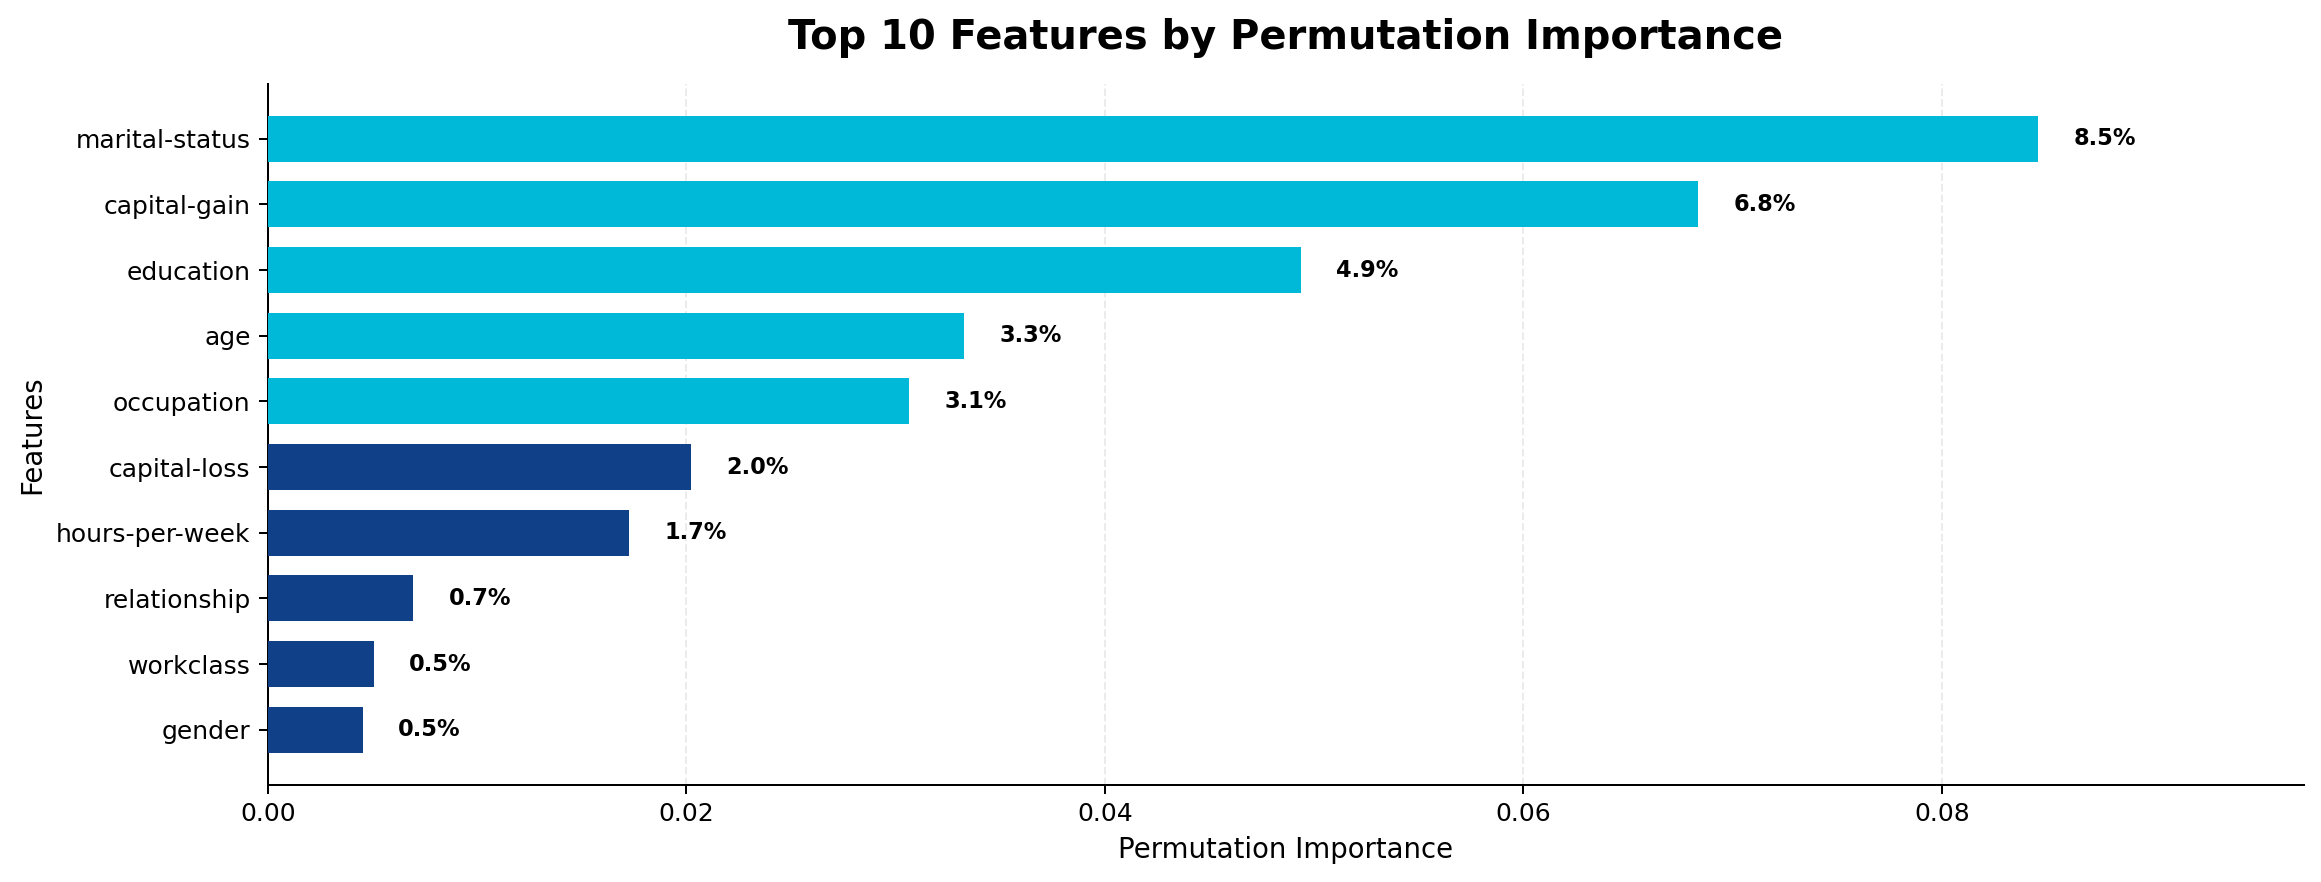

In [31]:
# Convert mean permutation importances into a Series
permutation_importances = pd.Series(
    r['importances_mean'],
    index=X_test.columns,
    name='Permutation Importance'
)

# Sort from highest to lowest
permutation_importances = permutation_importances.sort_values(
    ascending=False
)

ax = plot_importance_color(
    permutation_importances,
    top_n=10,
    highlight_n=5,
    figsize=(13, 5)
)

plt.show()


> - `marital-status` and `capital-gain` had the largest impact on the model's **Macro F1**, followed by `education`, `age`, and `occupation`.
> - This aligns with the business goal because these features capture demographic, financial, and employment-related information that can help distinguish between the `<=50K` and `>50K` income groups.
> - Features such as `gender` and `workclass` had a much smaller effect on the model's overall balanced performance.
> - These results show **predictive relationships**, not causal relationships.


In [32]:
def plot_income_by_feature(df, feature, figsize=(10, 5)):
    plot_df = df[[feature, 'income']].dropna().copy()
    income_order = ['<=50K', '>50K']
    colors= ['#104088','#00B8D8']

    custom_orders = {
        'education': ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
                      'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
                      'Prof-school', 'Doctorate'],
        'marital-status': ['Never-married', 'Married-civ-spouse', 'Married-AF-spouse',
                           'Married-spouse-absent', 'Separated', 'Divorced', 'Widowed']
    }

    if feature == 'capital-gain':
        positive = plot_df.loc[plot_df[feature] > 0, feature]
        q1, q2 = positive.quantile([1/3, 2/3])
        plot_df['Group'] = pd.cut(
            plot_df[feature],
            bins=[-np.inf, 0, q1, q2, np.inf],
            labels=['Zero', 'Low', 'Medium', 'High']
        )
        order = ['Zero', 'Low', 'Medium', 'High']

    elif pd.api.types.is_numeric_dtype(plot_df[feature]):
        plot_df['Group'] = pd.qcut(
            plot_df[feature].rank(method='first'),
            q=4,
            labels=['Low', 'Medium', 'High', 'Very High']
        )
        order = ['Low', 'Medium', 'High', 'Very High']

    else:
        order = custom_orders.get(feature, plot_df[feature].value_counts().index.tolist())
        order = [x for x in order if x in plot_df[feature].unique()]
        plot_df['Group'] = pd.Categorical(plot_df[feature], categories=order, ordered=True)

    income_percent = pd.crosstab(
        plot_df['Group'], plot_df['income'], normalize='index'
    ).mul(100).reindex(index=order, columns=income_order, fill_value=0)

    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    income_percent.plot(kind='bar', stacked=True, width=0.72, color=colors, ax=ax, zorder=3)

    for container in ax.containers:
        labels = [f'{v:.1f}%' if v >= 4 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=9, color='white', fontweight='bold')

    ax.set_title(
        f'Income Distribution Across {feature.replace("-", " ").title()}',
        fontsize=15, fontweight='bold', pad=14
    )
    ax.set_xlabel(feature.replace('-', ' ').title(), fontsize=11)
    ax.set_ylabel('Percentage of Individuals', fontsize=11)
    ax.set_ylim(0, 100)

    rotation = 35 if feature in ['education', 'marital-status'] else 0
    ax.tick_params(axis='x', rotation=rotation, labelsize=9)

    if rotation:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')

    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(
        title='Income',
        labels=['≤50K', '>50K'],
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()
    plt.show()

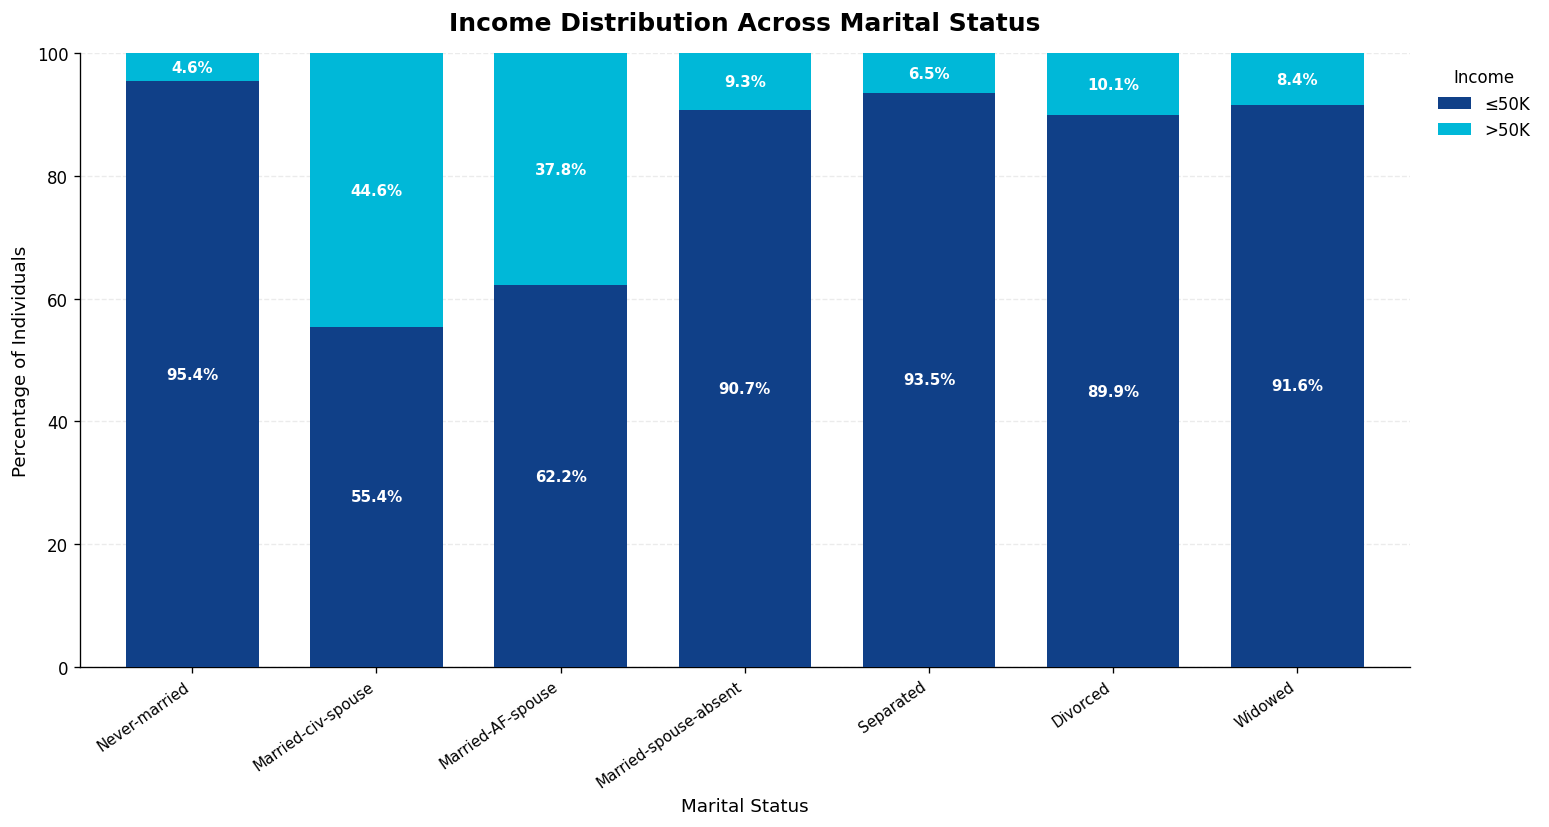

In [33]:
plot_income_by_feature(df, 'marital-status', figsize=(13, 7))

> - `Married-civ-spouse` and `Married-AF-spouse` have much higher proportions of individuals earning `>50K`, while most other marital-status groups are strongly concentrated in `<=50K`.
> - This supports `marital-status` being the most important feature in permutation importance, since it helps the model distinguish between income groups.
> - For the use case, this suggests household and marital characteristics contain useful information for income segmentation, although the relationship should not be interpreted as causal.

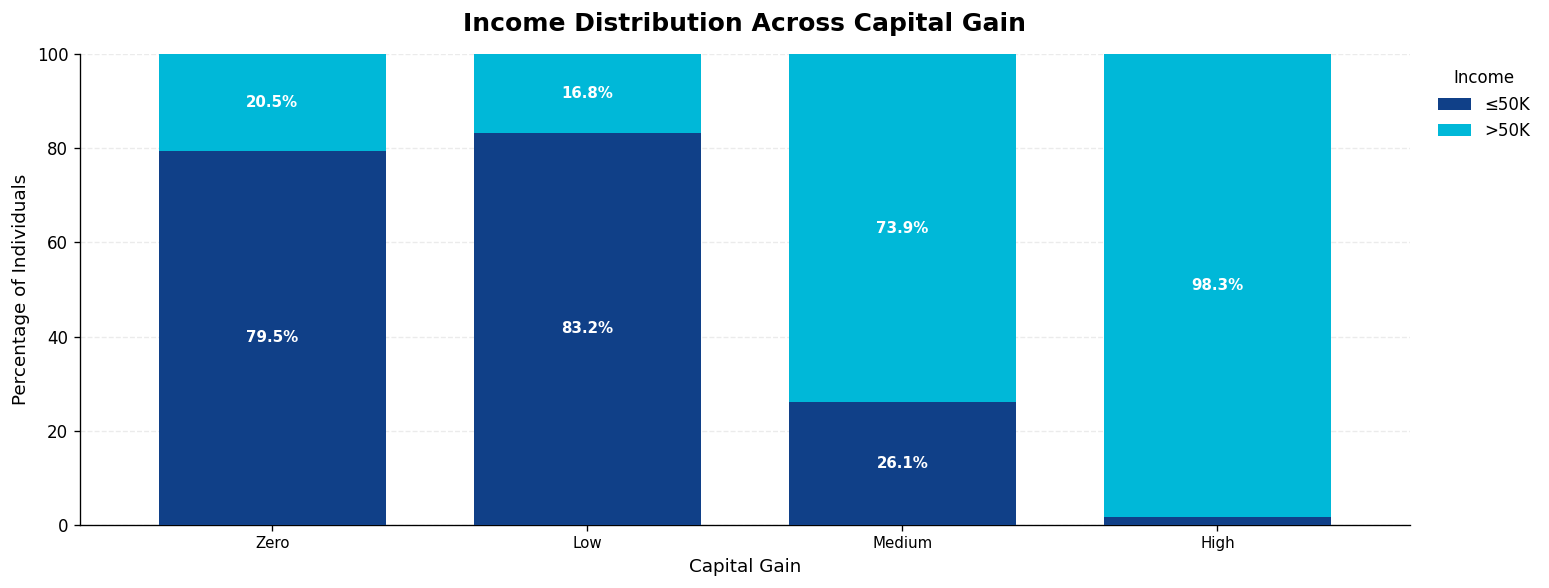

In [34]:
plot_income_by_feature(df, 'capital-gain', figsize=(13, 5))

> - Income level changes strongly as `capital-gain` increases. Around 74% of the medium group and 98% of the high group earn `>50K`, compared with only about 20% among those with no capital gain.
> - This makes `capital-gain` highly useful for identifying higher-income individuals and explains why it ranked second in permutation importance.
> - For income segmentation and economic analysis, capital gain provides a strong financial signal that can help separate the two income groups.

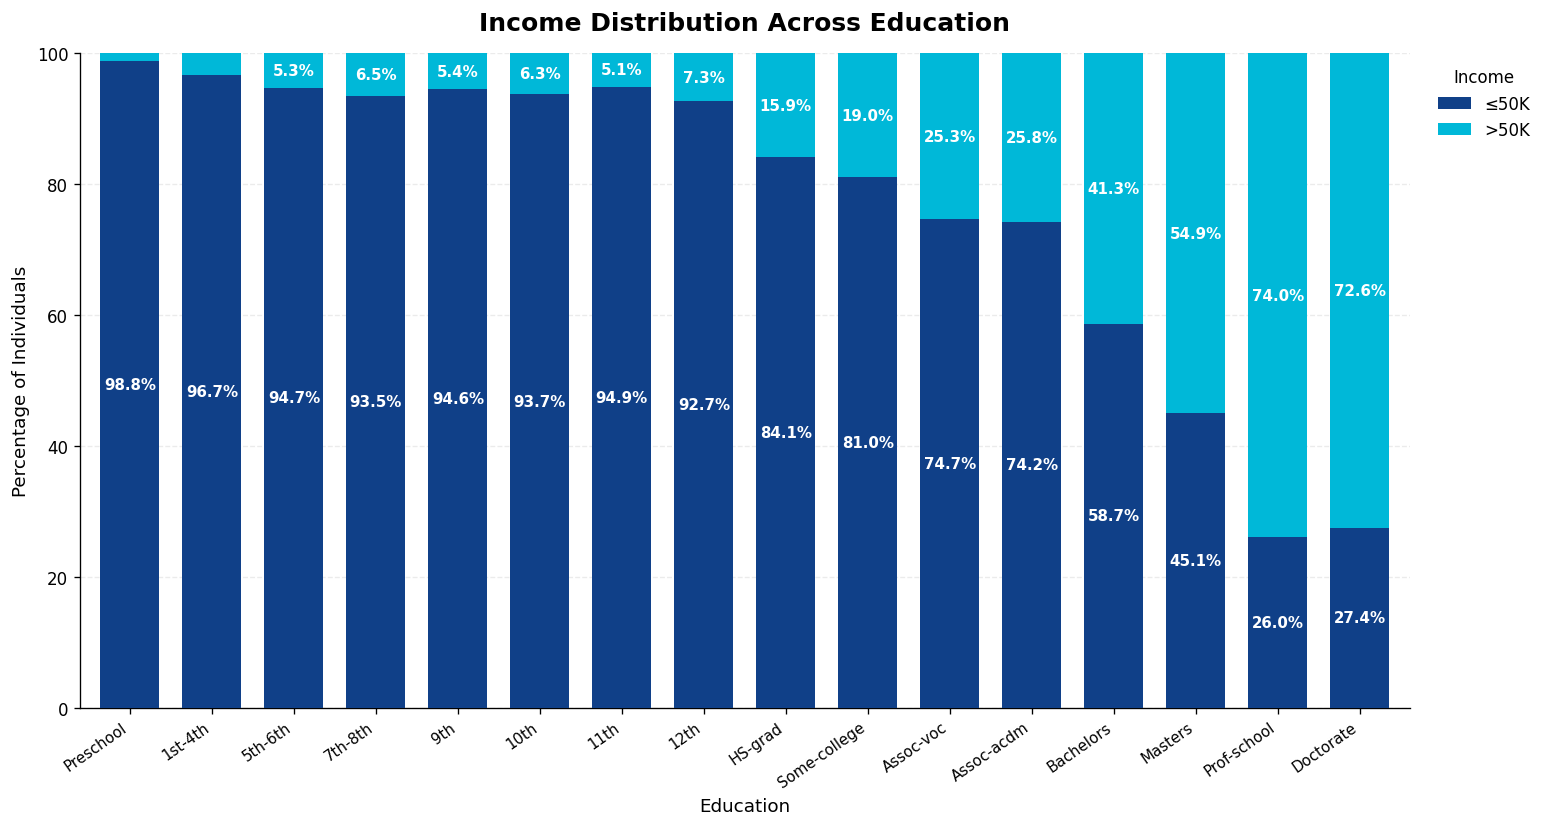

In [35]:
plot_income_by_feature(df, 'education', figsize=(13, 7))

> - The proportion earning `>50K` generally increases with education level. Only a small percentage of individuals with lower education levels earn `>50K`, compared with about 41% of those with a Bachelor's degree, 55% with a Master's, and over 70% with professional or doctoral education.
> - This supports `education` being one of the model's most important predictors and shows a clear relationship between education level and income group.
> - For the use case, education can help identify population segments with different income patterns and support broader economic or workforce analysis.

## Feature Engineering

- adding PCA/KMeans clusters did not improve XGBoost and reduced predictive performance.

- Manual FE features didnt improve nor reduce the models performance

- Embedded feature selection: XGBoost `SelectFromModel` with a median threshold reduced the feature set from 85 to 43 while keeping test Macro F1 at 0.82, showing that many processed features were redundant.

In [36]:
def engineer_features(X):
    X = X.copy()

    # 1. Drop fnlwgt: survey weight, not a real feature
    X = X.drop(columns=['fnlwgt'])

    # 2. Capital gain/loss: flags + net
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)
    X['has_capital_loss'] = (X['capital-loss'] > 0).astype(int)
    X['net_capital'] = X['capital-gain'] - X['capital-loss']

    # 3. Interaction features
    X['age_x_hours'] = X['age'] * X['hours-per-week']
    X['education_occupation'] = X['education'].astype(str) + '_' + X['occupation'].astype(str)

    # is_married collapsed from marital-status
    married_statuses = ['Married-civ-spouse', 'Married-AF-spouse']
    X['is_married'] = X['marital-status'].isin(married_statuses).astype(int)

    # 4. native-country: bucket to US / Non-US
    X['native-country'] = np.where(X['native-country'] == 'United-States', 'US', 'Non-US')

    return X

X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)

In [37]:
# categorical (nominal) added education_occupation, dropped native-country's old high-cardinality version (still nominal, just fewer levels now)
categorical_cols_fe = [
    'workclass', 'marital-status', 'occupation', 'relationship',
    'race', 'gender', 'native-country', 'education_occupation'
]

ordinal_cols_fe = ['education']

numerical_cols_fe = [
    'age', 'capital-gain', 'capital-loss', 'net_capital',
    'hours-per-week', 'age_x_hours',
    'has_capital_gain', 'has_capital_loss', 'is_married'
]

skewed_cols_fe = ['capital-gain', 'capital-loss']
plain_num_cols_fe = ['age', 'hours-per-week', 'age_x_hours', 'net_capital',
                     'has_capital_gain', 'has_capital_loss', 'is_married']

education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad',
                  'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']

ord_pipe = make_pipeline(
    OrdinalEncoder(categories=[education_order]),
    StandardScaler())
ord_tuple = ('Ordinal', ord_pipe, ['education'])

ohe_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
ohe_tuple = ('Categorical', ohe_pipe, categorical_cols_fe)

num_tuple = ('Numeric', StandardScaler(), plain_num_cols_fe)

skewed_pipe = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler())
skewed_tuple = ('Skewed Numeric', skewed_pipe, skewed_cols_fe)

preprocessor_fe = ColumnTransformer(
    [num_tuple, skewed_tuple, ord_tuple, ohe_tuple],
    verbose_feature_names_out=False
)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     27831
           1       0.81      0.68      0.74      8761

    accuracy                           0.88     36592
   macro avg       0.86      0.81      0.83     36592
weighted avg       0.88      0.88      0.88     36592



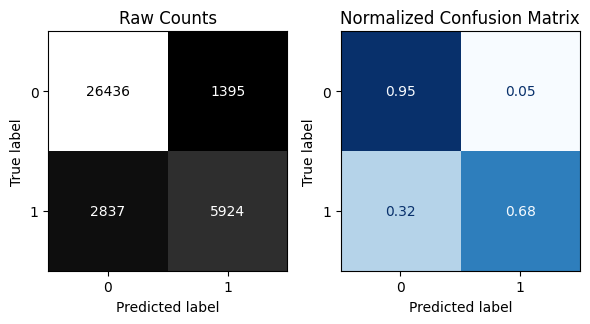


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      9278
           1       0.78      0.65      0.71      2920

    accuracy                           0.87     12198
   macro avg       0.84      0.79      0.81     12198
weighted avg       0.87      0.87      0.87     12198



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


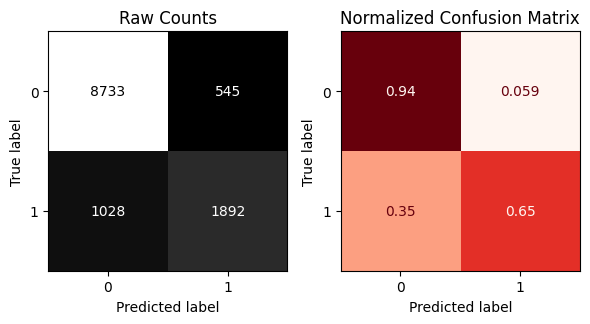

In [38]:
xgb_fe = XGBClassifier(random_state=42,
                        learning_rate=0.1,
                        max_depth=5,
                        n_estimators=200,
                        subsample=0.8,
                        colsample_bytree=0.8)

xgb_pipe_fe = make_pipeline(preprocessor_fe, xgb_fe)
xgb_pipe_fe.fit(X_train_fe, y_train_encoded)

evaluate_classification(xgb_pipe_fe, X_train_fe, y_train_encoded, X_test_fe, y_test_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


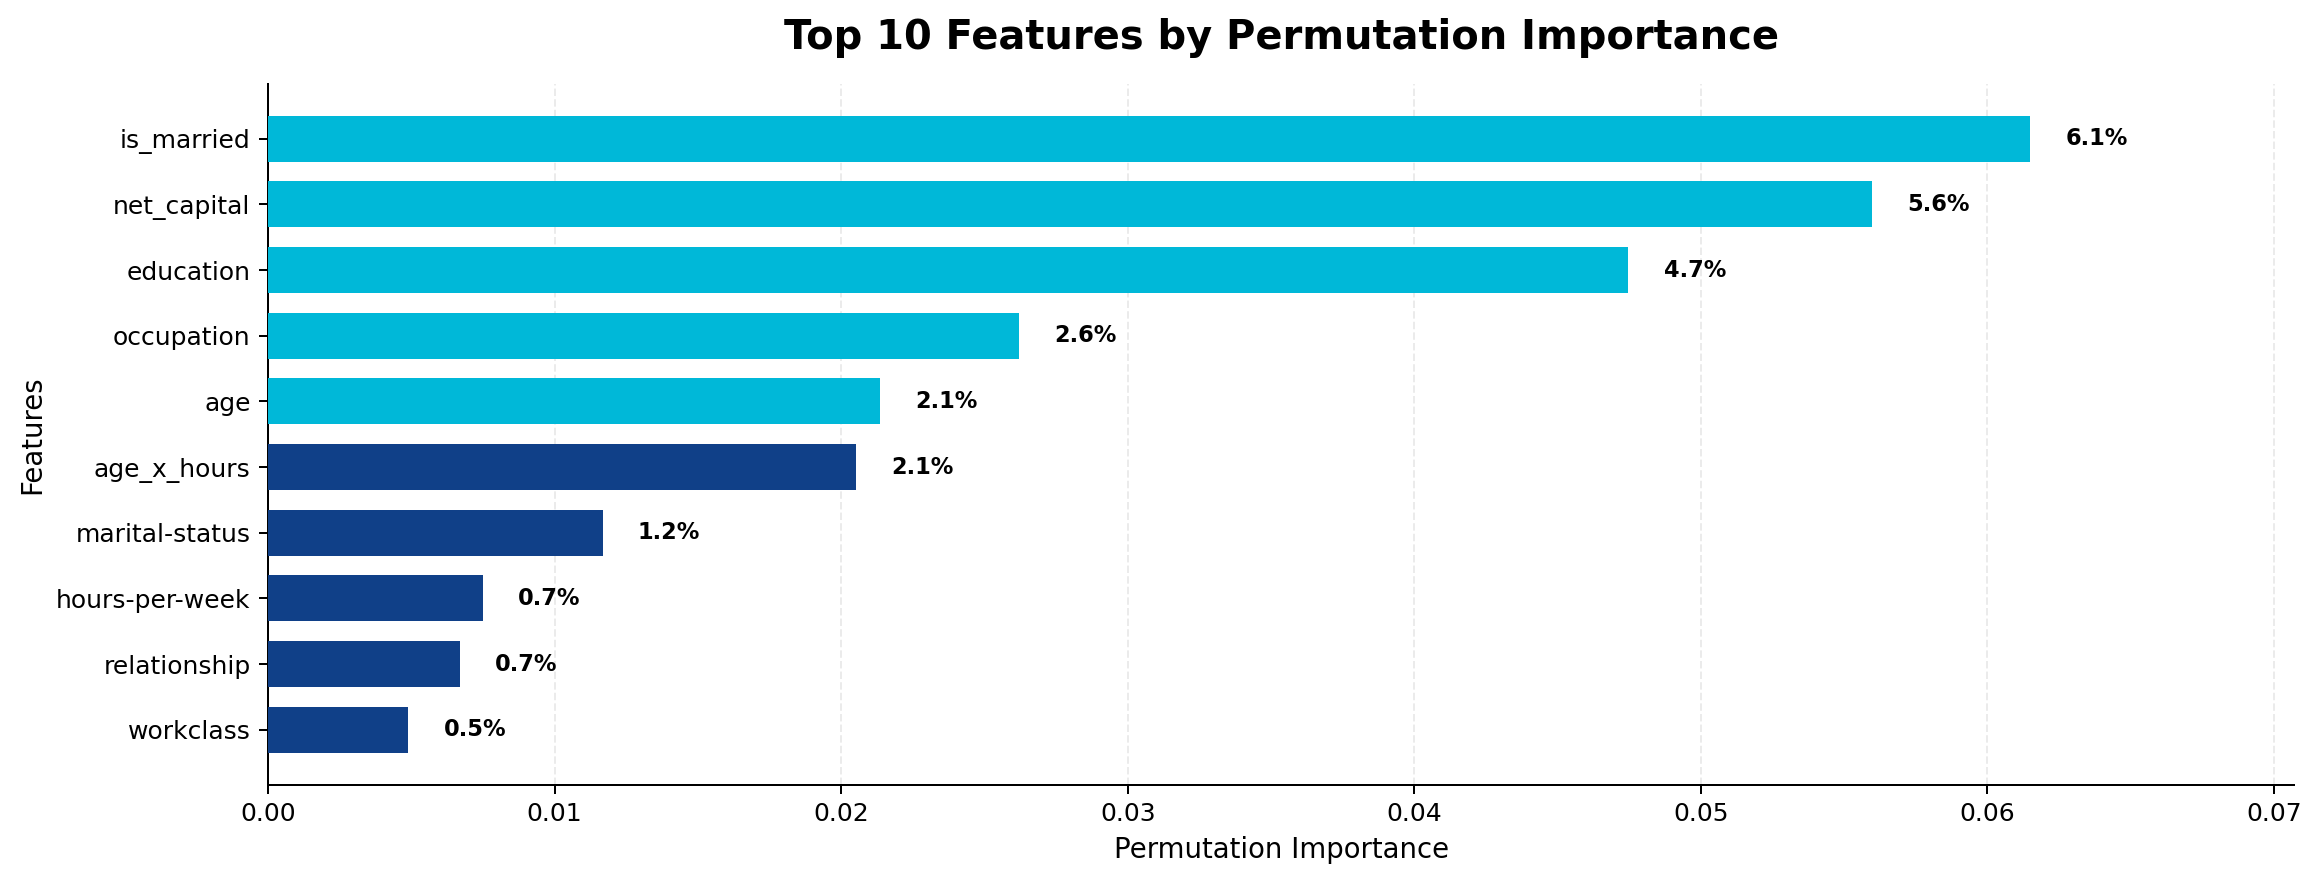

In [39]:
# Calculate permutation importance using unseen test data
r_fe = permutation_importance(
    xgb_pipe_fe,
    X_test_fe,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

new_feat_importance = pd.Series(r_fe['importances_mean'], index=X_test_fe.columns).sort_values(ascending=False)

ax = plot_importance_color(
    new_feat_importance,
    top_n=10,
    highlight_n=5,
    figsize=(13, 5)
)


In [40]:
def engineer_features_v2(X):
    X = X.copy()
    X = X.drop(columns=['fnlwgt'])
    X['net_capital'] = X['capital-gain'] - X['capital-loss']
    X['age_x_hours'] = X['age'] * X['hours-per-week']
    married_statuses = ['Married-civ-spouse', 'Married-AF-spouse']
    X['is_married'] = X['marital-status'].isin(married_statuses).astype(int)
    X['native-country'] = np.where(X['native-country'] == 'United-States', 'US', 'Non-US')
    return X
    # dropped: has_capital_gain, has_capital_loss, education_occupation

X_train_v2 = engineer_features_v2(X_train)
X_test_v2 = engineer_features_v2(X_test)

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.93     27831
           1       0.81      0.67      0.73      8761

    accuracy                           0.88     36592
   macro avg       0.86      0.81      0.83     36592
weighted avg       0.88      0.88      0.88     36592



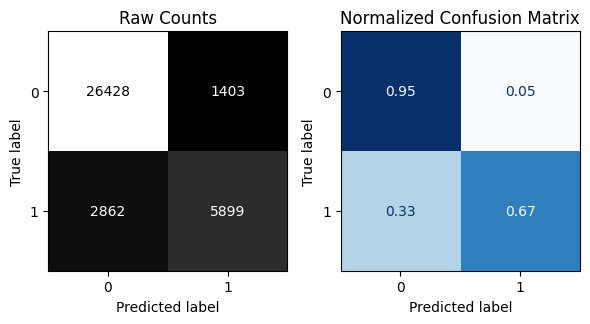


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      9278
           1       0.78      0.65      0.71      2920

    accuracy                           0.87     12198
   macro avg       0.84      0.80      0.81     12198
weighted avg       0.87      0.87      0.87     12198



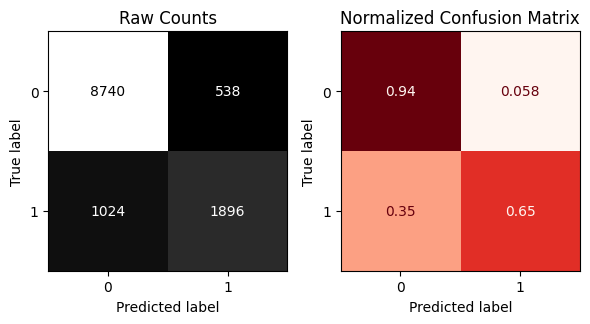

In [41]:
# ---- column groups ----
categorical_cols_v2 = [
    'workclass', 'marital-status', 'occupation', 'relationship',
    'race', 'gender', 'native-country'
]

ordinal_cols_v2 = ['education']

plain_num_cols_v2 = ['age', 'hours-per-week', 'age_x_hours', 'net_capital', 'is_married']

skewed_cols_v2 = ['capital-gain', 'capital-loss']

# ---- pipelines ----
education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad',
                    'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']

ord_pipe = make_pipeline(
    OrdinalEncoder(categories=[education_order]),
    StandardScaler())
ord_tuple = ('Ordinal', ord_pipe, ordinal_cols_v2)

ohe_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
ohe_tuple_v2 = ('Categorical', ohe_pipe, categorical_cols_v2)

num_tuple_v2 = ('Numeric', StandardScaler(), plain_num_cols_v2)

skewed_pipe = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler())
skewed_tuple = ('Skewed Numeric', skewed_pipe, skewed_cols_v2)

preprocessor_v2 = ColumnTransformer(
    [num_tuple_v2, skewed_tuple, ord_tuple, ohe_tuple_v2],
    verbose_feature_names_out=False
)

# ---- model ----
xgb_v2 = XGBClassifier(random_state=42,
                        learning_rate=0.1,
                        max_depth=5,
                        n_estimators=200,
                        subsample=0.8,
                        colsample_bytree=0.8)

xgb_pipe_v2 = make_pipeline(preprocessor_v2, xgb_v2)
xgb_pipe_v2.fit(X_train_v2, y_train_encoded)

evaluate_classification(
    xgb_pipe_v2,
    X_train_v2, y_train_encoded,
    X_test_v2, y_test_encoded
)

In [42]:
# params = {
#     'xgbclassifier__n_estimators': [100, 200],
#     'xgbclassifier__max_depth': [3, 5, 7],
#     'xgbclassifier__learning_rate': [0.03, 0.1],
#     'xgbclassifier__subsample': [0.8, 1.0],
#     'xgbclassifier__colsample_bytree': [0.8, 1.0],
#     'xgbclassifier__scale_pos_weight': [1, 1.5, 2, 2.5]
# }

# gridsearch_xgb = GridSearchCV(
#     xgb_pipe_v2,
#     params,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# gridsearch_xgb.fit(X_train_v2, y_train_encoded)

# print("\nBest Parameters:")
# print(gridsearch_xgb.best_params_)

# print("\nBest CV Score:")
# print(gridsearch_xgb.best_score_)

# best_xgb = gridsearch_xgb.best_estimator_

# evaluate_classification(
#     best_xgb,
#     X_train_v2,
#     y_train_encoded,
#     X_test_v2,
#     y_test_encoded
# )

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     27831
           1       0.74      0.76      0.75      8761

    accuracy                           0.88     36592
   macro avg       0.83      0.84      0.84     36592
weighted avg       0.88      0.88      0.88     36592



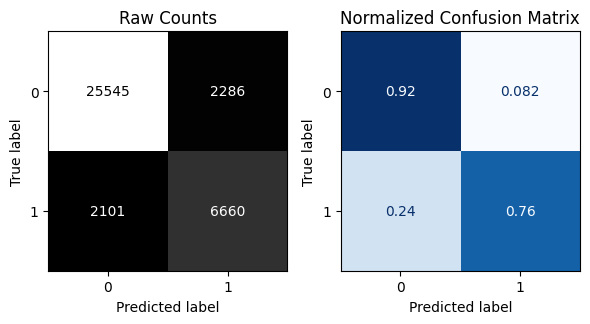


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      9278
           1       0.71      0.73      0.72      2920

    accuracy                           0.87     12198
   macro avg       0.81      0.82      0.82     12198
weighted avg       0.87      0.87      0.87     12198



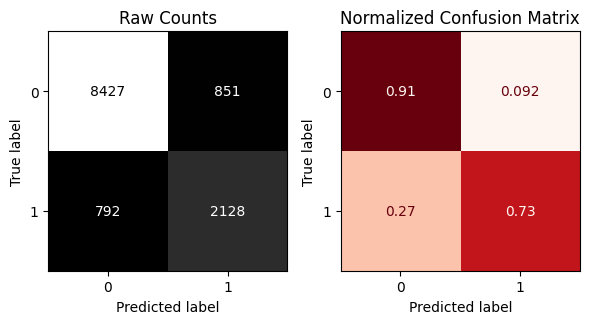

In [43]:
xgb_v2_final = XGBClassifier(random_state=42,
                       colsample_bytree= 0.8,
                       learning_rate=0.1,
                       max_depth=5,
                       n_estimators=200,
                       scale_pos_weight=1.5,
                       subsample= 1.0)

xgb_pipe_v2_final = make_pipeline(preprocessor_v2, xgb_v2_final)
xgb_pipe_v2_final.fit(X_train_v2, y_train_encoded)

evaluate_classification(
    xgb_pipe_v2_final,
    X_train_v2, y_train_encoded,
    X_test_v2, y_test_encoded
)

## Feature Selection

Three methods were tested:

- **SelectFromModel:** 47 to 24 features, Macro F1 = **0.81**
- **Backward Selection:** 47 to 46 features, little benefit
- **Forward Selection:** 47 to **9 features**, Macro F1 = **0.81**

The default XGBoost remained best at **0.82 Macro F1**, but forward selection kept similar performance with far fewer features, making it the most useful reduced feature set.

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     27831
           1       0.73      0.76      0.74      8761

    accuracy                           0.88     36592
   macro avg       0.83      0.83      0.83     36592
weighted avg       0.88      0.88      0.88     36592



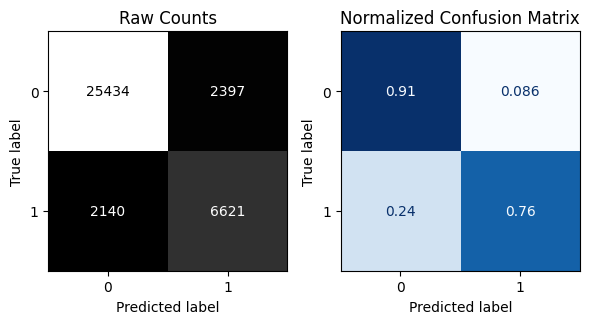


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      9278
           1       0.71      0.73      0.72      2920

    accuracy                           0.86     12198
   macro avg       0.81      0.82      0.81     12198
weighted avg       0.86      0.86      0.86     12198



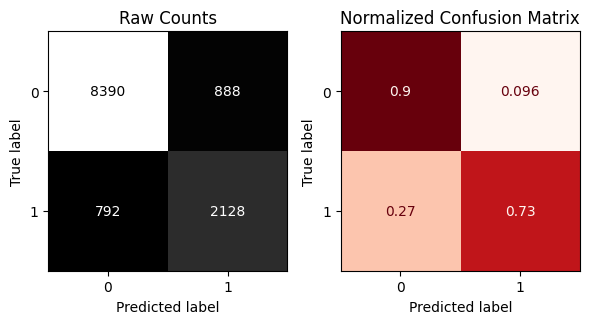

In [44]:
xgb_pipe_embedded_v2 = make_pipeline(
    preprocessor_v2,
    SelectFromModel(
        clone(xgb_v2_final),
        threshold='median'
    ),
    clone(xgb_v2_final)
)

xgb_pipe_embedded_v2.fit(X_train_v2, y_train_encoded)

evaluate_classification(
    xgb_pipe_embedded_v2,
    X_train_v2, y_train_encoded,
    X_test_v2, y_test_encoded
)

In [45]:
selector = xgb_pipe_embedded_v2.named_steps['selectfrommodel']

print("Features before:", selector.n_features_in_)
print("Features after:", selector.get_support().sum())
print("Removed:", selector.n_features_in_ - selector.get_support().sum())

# get feature names coming out of the preprocessor (before selection)
feature_names = xgb_pipe_embedded_v2.named_steps['columntransformer'].get_feature_names_out()

# boolean mask of which ones survived
support_mask = selector.get_support()

selected_features = feature_names[support_mask]
dropped_features = feature_names[~support_mask]

print(f"\nSelected ({len(selected_features)}):")
print(sorted(selected_features))

print(f"\nDropped ({len(dropped_features)}):")
print(sorted(dropped_features))

Features before: 47
Features after: 24
Removed: 23

Selected (24):
['age', 'age_x_hours', 'capital-gain', 'capital-loss', 'education', 'gender_Male', 'is_married', 'marital-status_Married-civ-spouse', 'marital-status_Never-married', 'net_capital', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_MISSING', 'occupation_Other-service', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Tech-support', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'workclass_Self-emp-not-inc']

Dropped (23):
['hours-per-week', 'marital-status_Married-AF-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Separated', 'marital-status_Widowed', 'native-country_US', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Machine-op-inspct', 'occupation_Priv-house-serv', 'occupation_Sales', 'occupation_Transport-moving', 'race_As

In [46]:
from sklearn.feature_selection import SequentialFeatureSelector

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     27831
           1       0.74      0.76      0.75      8761

    accuracy                           0.88     36592
   macro avg       0.83      0.84      0.84     36592
weighted avg       0.88      0.88      0.88     36592



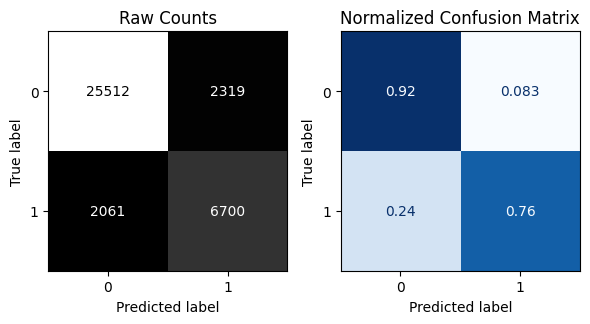


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      9278
           1       0.71      0.74      0.72      2920

    accuracy                           0.86     12198
   macro avg       0.81      0.82      0.82     12198
weighted avg       0.87      0.86      0.87     12198



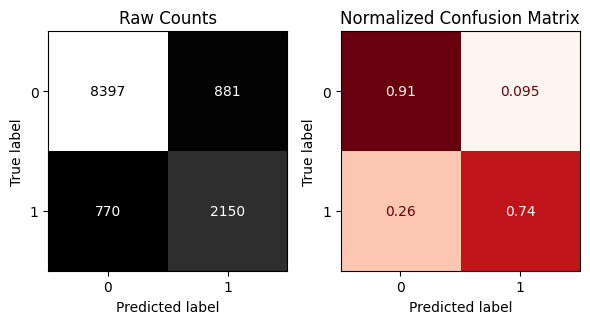

In [49]:
selector_back = SequentialFeatureSelector(
    estimator=clone(xgb_v2_final),
    n_features_to_select='auto',
    tol=0.001,              # stop removing once score would drop by more than this
    direction='backward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

xgb_pipe_wrapped_v2_backward = make_pipeline(
    preprocessor_v2,
    selector_back,
    clone(xgb_v2_final)
)

xgb_pipe_wrapped_v2_backward.fit(X_train_v2, y_train_encoded)

evaluate_classification(
    xgb_pipe_wrapped_v2_backward,
    X_train_v2, y_train_encoded,
    X_test_v2, y_test_encoded
)

In [50]:
selector_step_backward = xgb_pipe_wrapped_v2_backward.named_steps['sequentialfeatureselector']
feature_names_v2_backward = xgb_pipe_wrapped_v2_backward.named_steps['columntransformer'].get_feature_names_out()

support_mask_seq_backward = selector_step_backward.get_support()
selected_seq_backward = feature_names_v2_backward[support_mask_seq_backward]
dropped_seq_backward = feature_names_v2_backward[~support_mask_seq_backward]

print(f"Selected ({len(selected_seq_backward)}):")
print(sorted(selected_seq_backward))
print(f"\nDropped ({len(dropped_seq_backward)}):")
print(sorted(dropped_seq_backward))

Selected (46):
['age', 'age_x_hours', 'capital-gain', 'capital-loss', 'education', 'gender_Male', 'hours-per-week', 'is_married', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Widowed', 'native-country_US', 'net_capital', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_MISSING', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'workclass_Local-gov', 'workclass_MISSING', 'workclass_Never-work

--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     27831
           1       0.73      0.74      0.74      8761

    accuracy                           0.87     36592
   macro avg       0.83      0.83      0.83     36592
weighted avg       0.87      0.87      0.87     36592



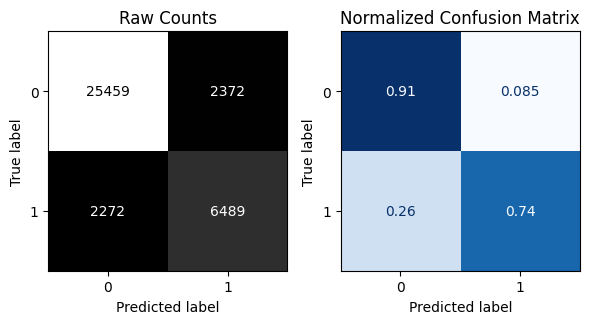


--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      9278
           1       0.71      0.72      0.72      2920

    accuracy                           0.86     12198
   macro avg       0.81      0.81      0.81     12198
weighted avg       0.86      0.86      0.86     12198



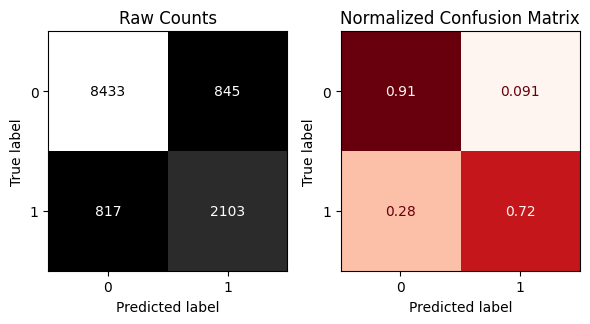

In [52]:
selector_forward = SequentialFeatureSelector(
    estimator=clone(xgb_v2_final),
    n_features_to_select='auto',
    tol=0.001,              # stop removing once score would drop by more than this
    direction='forward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

xgb_pipe_wrapped_v2_forward = make_pipeline(
    preprocessor_v2,
    selector_forward,
    clone(xgb_v2_final)
)

xgb_pipe_wrapped_v2_forward.fit(X_train_v2, y_train_encoded)

evaluate_classification(
    xgb_pipe_wrapped_v2_forward,
    X_train_v2, y_train_encoded,
    X_test_v2, y_test_encoded
)

In [53]:
selector_step_forward = xgb_pipe_wrapped_v2_forward.named_steps['sequentialfeatureselector']
feature_names_v2_forward = xgb_pipe_wrapped_v2_forward.named_steps['columntransformer'].get_feature_names_out()

support_mask_seq_forward = selector_step_forward.get_support()
selected_seq_forward = feature_names_v2_forward[support_mask_seq_forward]
dropped_seq_forward = feature_names_v2_forward[~support_mask_seq_forward]

print(f"Selected ({len(selected_seq_forward)}):")
print(sorted(selected_seq_forward))
print(f"\nDropped ({len(dropped_seq_forward)}):")
print(sorted(dropped_seq_forward))

Selected (9):
['age', 'age_x_hours', 'education', 'is_married', 'net_capital', 'occupation_Exec-managerial', 'occupation_Other-service', 'relationship_Not-in-family', 'workclass_Self-emp-not-inc']

Dropped (38):
['capital-gain', 'capital-loss', 'gender_Male', 'hours-per-week', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'native-country_US', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_MISSING', 'occupation_Machine-op-inspct', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship

## Neural Networks

In [73]:
encoder= LabelEncoder()
y_train_enc= encoder.fit_transform(y_train)
y_test_enc= encoder.transform(y_test)

classes= encoder.classes_

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

input_shape = X_train_pre.shape[1]

input_shape

85

In [74]:
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train_pre,
    y_train_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_train_enc
)

In [75]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6, 12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    # Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics), figsize=figsize)

    # If there is only one metric, make axes iterable
    if len(metrics) == 1:
        axes = [axes]

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]

        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(
            epochs,
            metric_values,
            label=metric_name,
            marker=marker
        )

        # Check if val_{metric} exists. If so, plot it.
        val_metric_name = f"val_{metric_name}"

        if val_metric_name in history.history:

            # Get validation values and plot
            metric_values = history.history[val_metric_name]

            ax.plot(
                epochs,
                metric_values,
                label=val_metric_name,
                marker=marker
            )

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)

    fig.tight_layout()

    return fig, axes

# model evaluation function
def classification_metrics(y_true,y_pred,label='',output_dict=False,figsize=(8, 4),normalize='true',cmap='Blues',colorbar=False):
    # Get the classification report
    report = classification_report(y_true, y_pred)

    # Print header and report
    header = "--" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    # CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Create a confusion matrix of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=None,cmap='gist_gray',colorbar=colorbar,ax=axes[0])
    axes[0].set_title("Raw Counts")

    # Create a normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_true,y_pred,normalize=normalize,cmap=cmap,colorbar=colorbar,ax=axes[1] )
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary version of classification_report
    if output_dict == True:
        report_dict = classification_report(
            y_true,
            y_pred,
            output_dict=True
        )
        return report_dict
def evaluate_classification(model,X_train,y_train,X_test,y_test,figsize=(6, 4),normalize='true',output_dict=False,cmap_train="Blues",cmap_test="Reds",colorbar=False):
    # Helper function to get predictions in the correct format
    def get_predictions(model, X_data):
        y_pred = model.predict(X_data)
        # Check if model output is probabilities (Keras/TensorFlow model)
        if isinstance(model, (tf.keras.Model, tf.keras.Sequential)):
            # If it's a binary classification output (shape (n_samples, 1))
            if y_pred.shape[-1] == 1:
                return (y_pred > 0.5).astype(int).flatten()
            # If it's a multiclass classification output (shape (n_samples, n_classes > 1))
            elif y_pred.shape[-1] > 1:
                return np.argmax(y_pred, axis=1)
        # Otherwise, assume it's a scikit-learn model already returning class labels
        return y_pred

    # Get predictions for training data
    y_train_pred = get_predictions(model, X_train)

    # Call the helper function to obtain classification metrics for training data
    results_train = classification_metrics(y_train,y_train_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')

    print()

    # Get predictions for test data
    y_test_pred = get_predictions(model, X_test)

    # Call the helper function to obtain classification metrics for test data
    results_test = classification_metrics( y_test, y_test_pred,output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data')

    if output_dict == True:
        # Store results in a dictionary if output_dict is True
        results_dict = {
            'train': results_train,
            'test': results_test
        }
        return results_dict

In [59]:
base_model = Sequential([
    Dense(128, activation='relu', input_dim=input_shape),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
    ])

# Compile model
base_model.compile(
    optimizer='adam',
    loss='bce',
    metrics=['accuracy',
              metrics.Precision(),
              metrics.Recall()])

base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 19,329 (75.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8344 - loss: 0.3516 - precision: 0.6909 - recall: 0.5576 - val_accuracy: 0.8544 - val_loss: 0.3260 - val_precision: 0.7115 - val_recall: 0.6587
Epoch 2/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8448 - loss: 0.3294 - precision: 0.7147 - recall: 0.5857 - val_accuracy: 0.8544 - val_loss: 0.3199 - val_precision: 0.7450 - val_recall: 0.5953
Epoch 3/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8487 - loss: 0.3235 - precision: 0.7232 - recall: 0.5961 - val_accuracy: 0.8546 - val_loss: 0.3214 - val_precision: 0.7461 - val_recall: 0.5953
Epoch 4/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8491 - loss: 0.3231 - precision: 0.7252 - recall: 0.5954 - val_accuracy: 0.8546 - val_loss: 0.3218 - val_precision: 0.7409 - val_recall: 0.6039
Epoch 5/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8502 - loss: 0.3205 - precision: 0.7270 - recall: 0.5992 - val_accuracy: 0.8537 - val_loss: 0

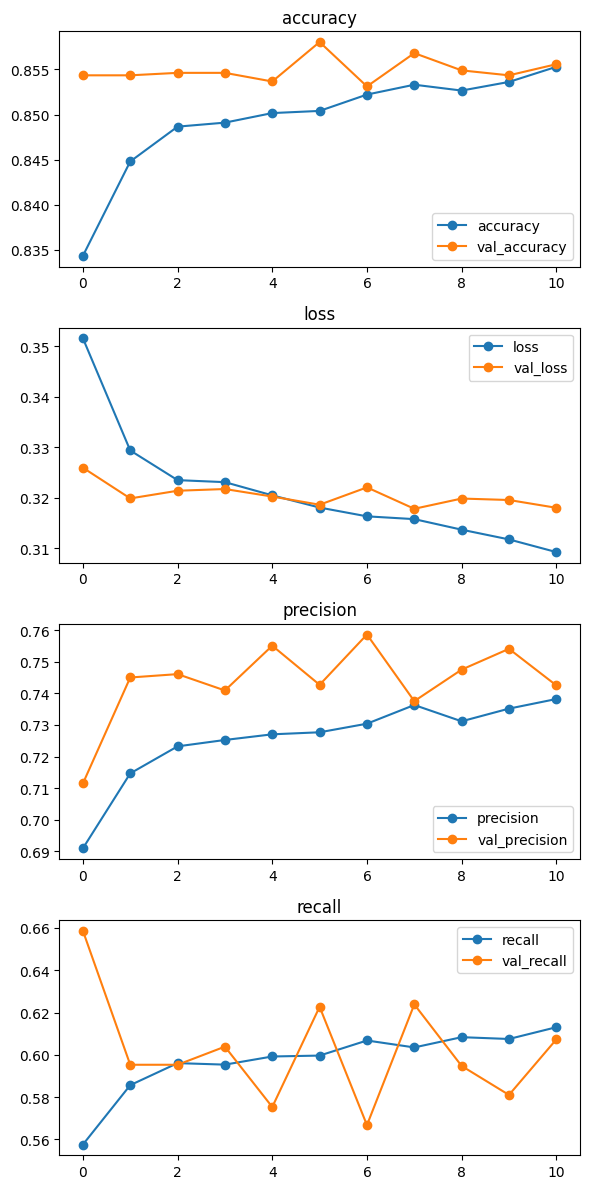

In [60]:
# Early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

base_history= base_model.fit(X_nn_train,
                        y_nn_train,
                        validation_data=(X_nn_val, y_nn_val),
                        epochs=50,
                        callbacks=[early_stopping])

plot_history(base_history);

1144/1144 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     27831
           1       0.74      0.62      0.68      8761

    accuracy                           0.86     36592
   macro avg       0.81      0.78      0.79     36592
weighted avg       0.85      0.86      0.85     36592



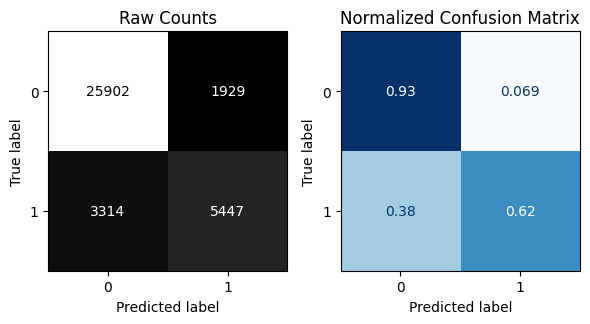


382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      9278
           1       0.73      0.60      0.66      2920

    accuracy                           0.85     12198
   macro avg       0.80      0.77      0.78     12198
weighted avg       0.84      0.85      0.85     12198



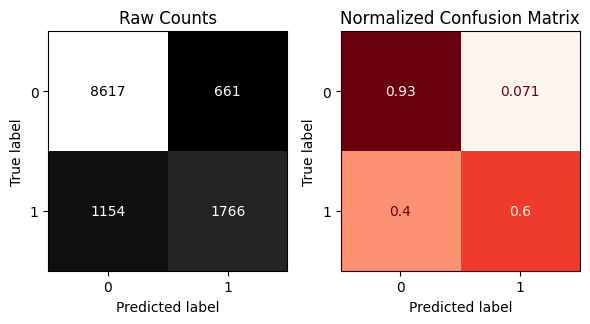

In [61]:
# Evaluate
evaluate_classification(
    base_model,
    X_train_pre, y_train_enc,
    X_test_pre, y_test_enc)

### Weighted Model

In [62]:
# Calculate class weights using only the training portion
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weights = dict(
    zip(np.unique(y_train_enc), class_weights_array)
)

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.657396428443103), np.int64(1): np.float64(2.0883460792147015)}


In [63]:
weighted_model = Sequential([
    Dense(128, activation='relu', input_dim=input_shape),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
    ])

# Compile model
weighted_model.compile(
    optimizer='adam',
    loss='bce',
    metrics=['accuracy',
              metrics.Precision(),
              metrics.Recall()])

weighted_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 19,329 (75.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7807 - loss: 0.4222 - precision_1: 0.5261 - recall_1: 0.8445 - val_accuracy: 0.7997 - val_loss: 0.3865 - val_precision_1: 0.5523 - val_recall_1: 0.8619
Epoch 2/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7929 - loss: 0.3939 - precision_1: 0.5426 - recall_1: 0.8600 - val_accuracy: 0.7899 - val_loss: 0.4105 - val_precision_1: 0.5375 - val_recall_1: 0.8750
Epoch 3/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8002 - loss: 0.3865 - precision_1: 0.5528 - recall_1: 0.8666 - val_accuracy: 0.8007 - val_loss: 0.3883 - val_precision_1: 0.5535 - val_recall_1: 0.8653
Epoch 4/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8028 - loss: 0.3827 - precision_1: 0.5566 - recall_1: 0.8663 - val_accuracy: 0.7839 - val_loss: 0.4102 - val_precision_1: 0.5289 - val_recall_1: 0.8881
Epoch 5/50
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8020 - loss: 0.3807 - precision_1: 0.5551 - recall_1: 0.8724 -

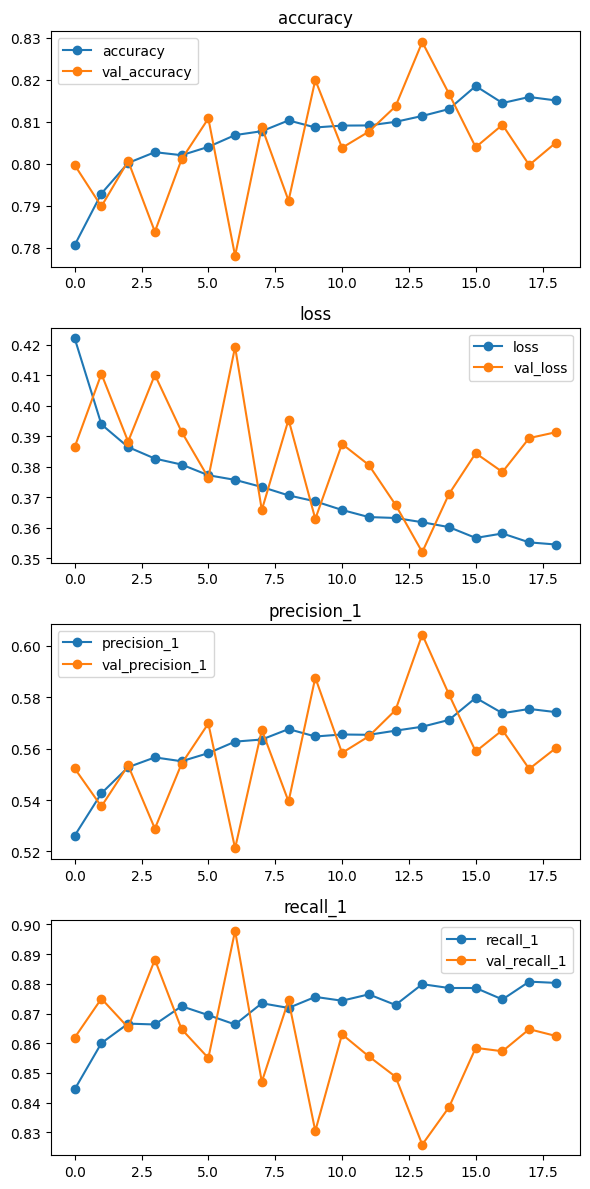

In [64]:
# Early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

weighted_history= weighted_model.fit(X_nn_train,
                        y_nn_train,
                        validation_data=(X_nn_val, y_nn_val),
                        epochs=50,
                        callbacks=[early_stopping],
                        class_weight=class_weights)

plot_history(weighted_history);

1144/1144 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.84      0.89     27831
           1       0.62      0.84      0.71      8761

    accuracy                           0.84     36592
   macro avg       0.78      0.84      0.80     36592
weighted avg       0.86      0.84      0.84     36592



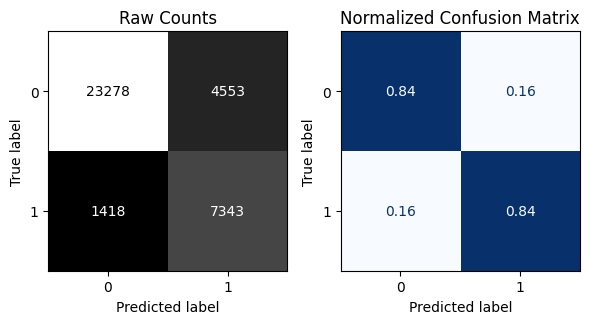


382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
--------------------------------------------------------------------------------------------------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      9278
           1       0.60      0.82      0.69      2920

    accuracy                           0.83     12198
   macro avg       0.77      0.82      0.79     12198
weighted avg       0.86      0.83      0.83     12198



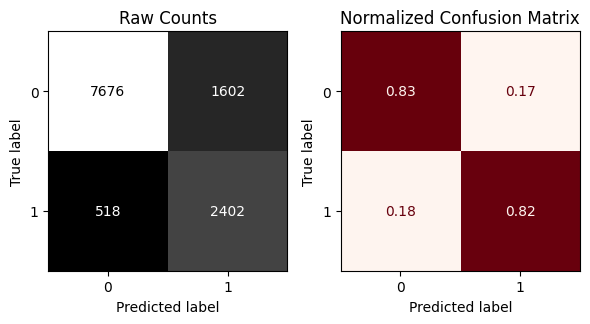

In [65]:
# Evaluate
evaluate_classification(
    weighted_model,
    X_train_pre, y_train_enc,
    X_test_pre, y_test_enc)

## Keras Tuner

In [ ]:
def build_model(hp, input_shape):
    model = Sequential()
    model.add(Dense(
        units=hp.Choice('units_1', [64, 128]),
        activation='relu',
        input_dim=input_shape,
        kernel_regularizer=l1_l2(
            l1=hp.Choice('l1_1', [0.0, 1e-5, 1e-4]),
            l2=hp.Choice('l2_1', [0.0, 1e-4, 1e-3])
        )
    ))

    model.add(Dropout(
        hp.Choice('dropout', [0.2, 0.3, 0.4])
    ))

    model.add(Dense(
        units=hp.Choice('units_2', [32, 64]),
        activation='relu',
        kernel_regularizer=l1_l2(
            l1=hp.Choice('l1_2', [0.0, 1e-5, 1e-4]),
            l2=hp.Choice('l2_2', [0.0, 1e-4, 1e-3])
        )
    ))

    model.add(Dense(1, activation='sigmoid'))

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
    optimizer_name = hp.Choice('optimizer', ['adam', 'rmsprop', 'nadam'])

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.Nadam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

In [ ]:
# folder = 'KerasTuner/'
# os.makedirs(folder, exist_ok=True)

# tuner = kt.Hyperband(
#     lambda hp: build_model(hp, input_shape),
#     objective='val_accuracy',
#     max_epochs=50,
#     directory=folder,
#     overwrite=True,
#     seed=42,
#     project_name='Income_Tuning'
# )

# # Early stopping
# early_stopping = EarlyStopping(
#     monitor='val_accuracy',
#     patience=5,
#     restore_best_weights=True
# )

# tuner.search(
#     X_nn_train,
#     y_nn_train,
#     validation_data=(X_nn_val, y_nn_val),
#     epochs=50,
#     callbacks=[early_stopping]
# )

In [ ]:
# best_hps= tuner.get_best_hyperparameters()[0]
# print(best_hps.values)

# # obtain best model
# best_model= tuner.get_best_models()[0]
# best_model.summary()

In [ ]:
best_hps = kt.HyperParameters()

best_hps.values = {'units_1': 64,
                   'l1_1': 0.0,
                   'l2_1': 0.0,
                   'dropout': 0.2,
                   'units_2': 32,
                   'l1_2': 1e-05,
                   'l2_2': 0.0,
                   'learning_rate': 0.001,
                   'optimizer': 'nadam'}


final_model = build_model(best_hps, input_shape)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

final_model.summary()

In [ ]:
history = final_model.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_nn_val, y_nn_val),
    epochs=100,
    callbacks=[early_stopping])

In [ ]:
plot_history(history);

In [ ]:
evaluate_classification(final_model,X_train_pre, y_train_enc, X_test_pre, y_test_enc)